In [1]:
%matplotlib widget

Per ogni sorgente modificare:
- z e controllare che lambda lines corrisponda
- sigma e seeing
- n_component
- regione estrazione cielo
- taglio immagine in y
- funzioni di plot e model_convolved
- bounds_HA (ampiezza dell'intervallo sulle x è +- la metà del seeing) e bounds
- salvataggio fit

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_1263/FORS2.2022-01-06T07_26_01.965/Mrk-1263_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_1263/FORS2.2022-01-06T07_26_01.965/Mrk-1263_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     359   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        40   (2094, 964)   float32   


In [4]:
image_cut = image[56:156, 0:1890]
image_error_cut = image_error[56:156, 0:1890]

Text(0.5, 0, 'wavelength')

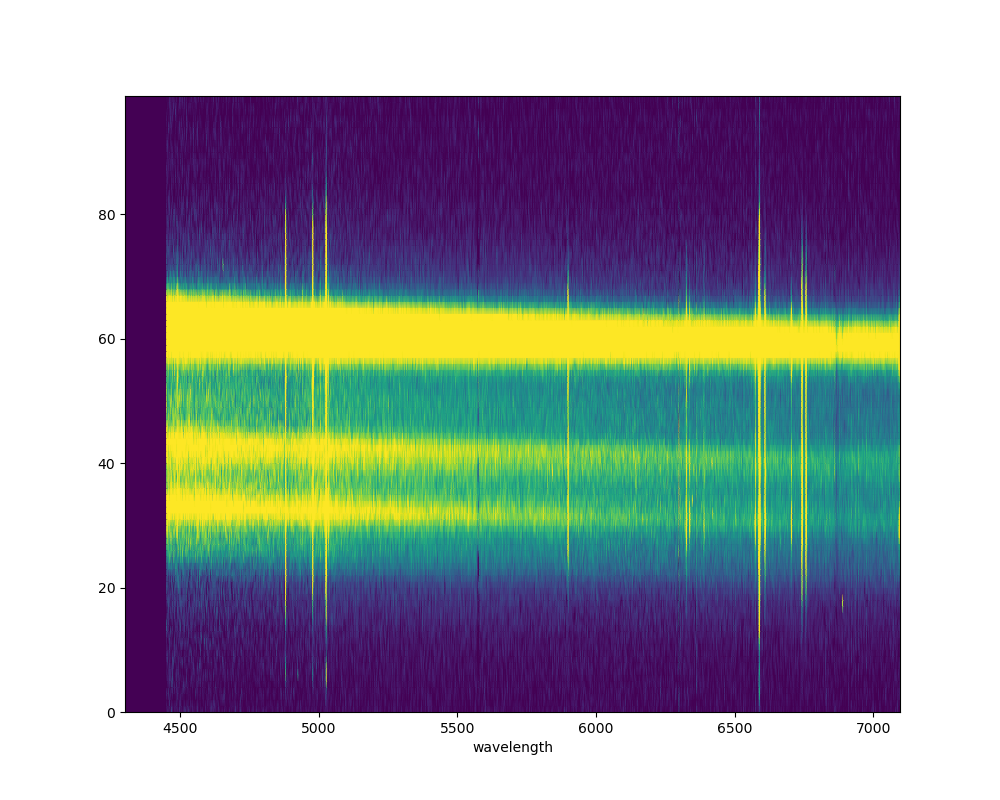

In [5]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10,8))
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin=np.percentile(image_cut, 15), vmax=np.percentile(image_cut, 90))
plt.xlabel('wavelength')

## Redshift or the lines in air

In [6]:
z = 0.00442
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_1263/FORS2.2022-01-06T07_26_01.965/PSF/Real_seeing_Mrk1263.txt")
sigmas = seeing / 2.35
print(sigmas)

[1.00950914 1.1229436  1.00774775 0.9959783  1.11963204 1.01319149]


## Sky lines

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_1263/FORS2.2022-01-06T07_26_01.965/Mrk-1263_MAPPED_FLUX_ALL_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     359   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        40   (2094, 964)   float32   


Text(0.5, 0, 'wavelength')

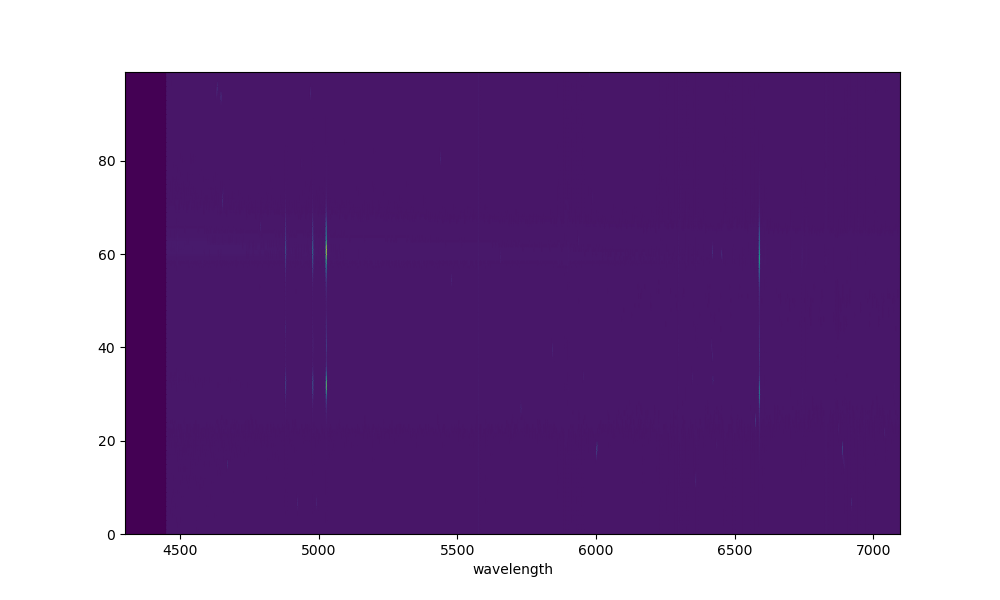

In [7]:
hdul2 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_1263/FORS2.2022-01-06T07_26_01.965/Mrk-1263_MAPPED_FLUX_ALL_SCI_LSS_U1.fits")
hdul2.info()
image2 = hdul2[0].data
image_cut2 = image2[56:156, 0:1890]

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10, 6))
plt.pcolormesh(x_grid, y_grid, image_cut2, shading='gouraud')#, vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelength')

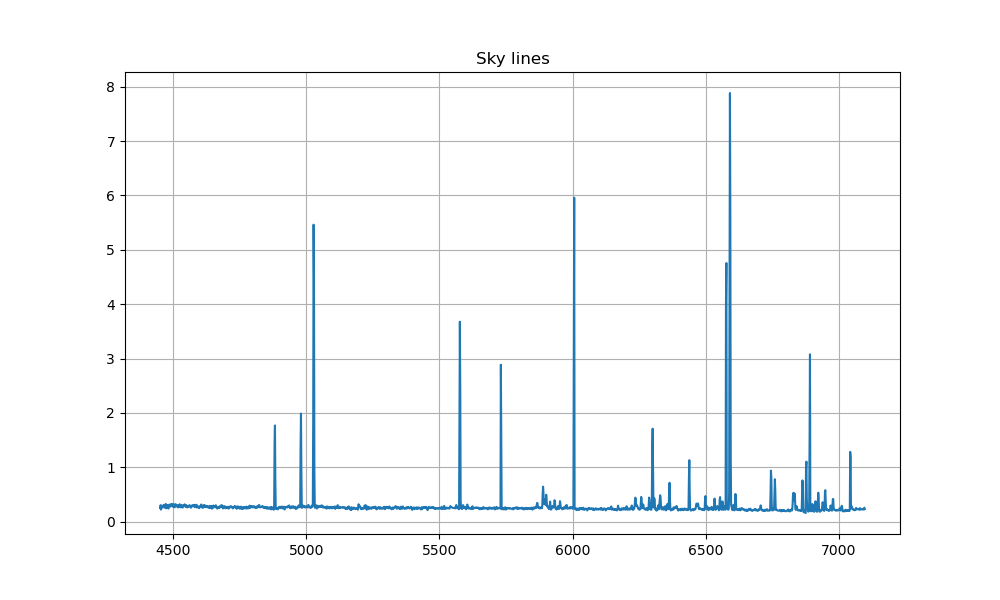

In [8]:
mask_sky = (y > 18)*(y < 28)
mask_wv = wv > 4451
image_sky = image_cut2[np.ix_(mask_sky, mask_wv)]
radial_profile_sky = np.sum(image_sky, axis = 0)
plt.figure(figsize=(10, 6))
plt.plot(wv[mask_wv], radial_profile_sky)

plt.grid()
plt.title(r'Sky lines')

plt.savefig('Sky_lines')

## H$\alpha$

Text(0.5, 1.0, 'H$\\alpha$')

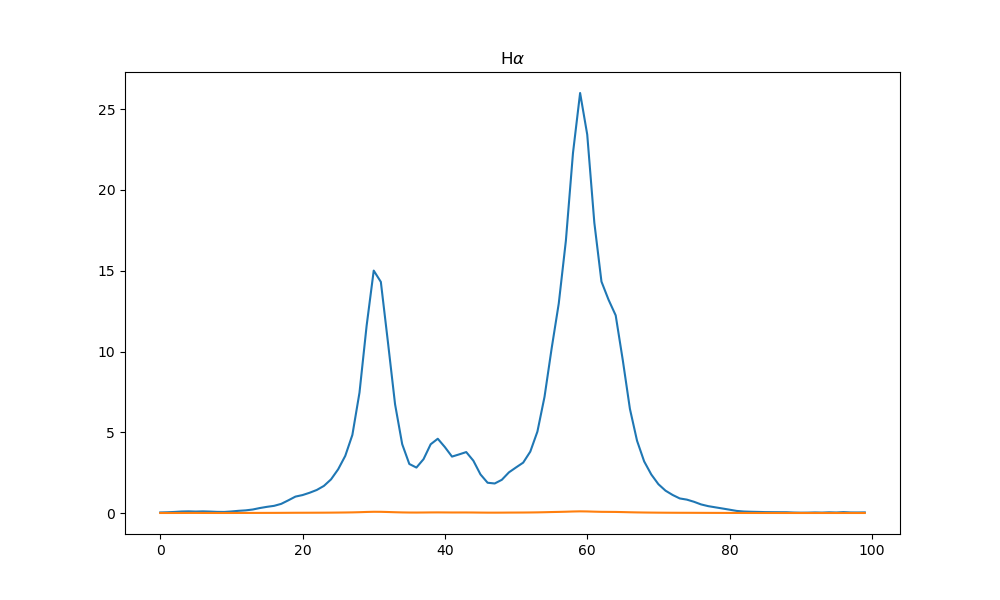

In [9]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

sky_err = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_1263/FORS2.2022-01-06T07_26_01.965/Propag_errori/Sky_errors.txt")
real_errors_HA = np.sqrt(radial_profile_error_HA**2+(sky_err[2])**2+(0.04*radial_profile_HA)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [10]:
n_component = 5

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, sigma, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])+
        sersic_1d(x_hr, *params[16:20]) #+
        #sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs, sigma):
    y_model = model_convolved(x, sigma, *params)
    return np.sum((y_obs - y_model)**2)

def sersic_1d_convolved(x, I_e, r_e, n, x_0, sigma):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 43)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 43)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

bounds_HA =[
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (25, 35),   # x_0: posizione da 0 a 100

    (0, 1),
    (0, 50),
    (0.1, 10),
    (35, 40),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (40, 45),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (55, 63),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (60, 65)
]

def save_params(params_curve, covariance, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    I_e_err = np.zeros(n_component)
    r_e_err = np.zeros(n_component)
    n_err = np.zeros(n_component)
    x_0_err = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        I_e_err[i] = np.sqrt(np.diag(covariance)[i*4])
        r_e_err[i] = np.sqrt(np.diag(covariance)[(i*4)+1])
        n_err[i] = np.sqrt(np.diag(covariance)[(i*4)+2])
        x_0_err[i] = np.sqrt(np.diag(covariance)[(i*4)+3])
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    print(np.sqrt(np.diag(covariance)))
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, sigma, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2_reduced)

    param_dict = {}
    error_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
        error_dict[component_name] = [I_e_err[i], r_e_err[i], n_err[i], x_0_err[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    df_errors = pd.DataFrame(data=error_dict, index=['I_e error', 'r_e error', 'n error', 'x_0 error'])
    
    # Salva file CSV
    if line_name:
        param_filename = f"{line_name}_{output_prefix}.csv"
        error_filename = f"{line_name}_{output_prefix}_errors.csv"
    
    df_params.to_csv(param_filename, float_format='%.4f')
    df_errors.to_csv(error_filename, float_format='%.4f')
    return chi2_reduced, dof, chi2

def save_params_diff(params_curve, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    param_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    
    output_dir = "Diff_params"
    os.makedirs(output_dir, exist_ok=True)

    # Salva file CSV nella cartella Diff_params
    if line_name:
        param_filename = os.path.join(output_dir, f"{line_name}_{output_prefix}_diff.csv")
    
    df_params.to_csv(param_filename, float_format='%.4f')

In [11]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 1107.3318518950205
differential_evolution step 2: f(x)= 536.3150460835567
differential_evolution step 3: f(x)= 536.3150460835567
differential_evolution step 4: f(x)= 536.3150460835567
differential_evolution step 5: f(x)= 536.3150460835567
differential_evolution step 6: f(x)= 498.64412865960844
differential_evolution step 7: f(x)= 498.64412865960844
differential_evolution step 8: f(x)= 498.64412865960844
differential_evolution step 9: f(x)= 407.7126992961905
differential_evolution step 10: f(x)= 407.7126992961905
differential_evolution step 11: f(x)= 407.7126992961905
differential_evolution step 12: f(x)= 407.7126992961905
differential_evolution step 13: f(x)= 254.0205115556144
differential_evolution step 14: f(x)= 254.0205115556144
differential_evolution step 15: f(x)= 254.0205115556144
differential_evolution step 16: f(x)= 254.0205115556144
differential_evolution step 17: f(x)= 254.0205115556144
differential_evolution step 18: f(x)= 254.02051155561

Sérsic 1: I_e=1.0000, r_e=9.0318, n=1.9728, x_0=30.3369
Sérsic 2: I_e=1.0000, r_e=1.2112, n=1.2209, x_0=38.9604
Sérsic 3: I_e=1.0000, r_e=1.2300, n=0.8668, x_0=42.7015
Sérsic 4: I_e=1.0000, r_e=17.3925, n=2.2414, x_0=58.8803
Sérsic 5: I_e=1.0000, r_e=4.0225, n=1.4365, x_0=63.3841


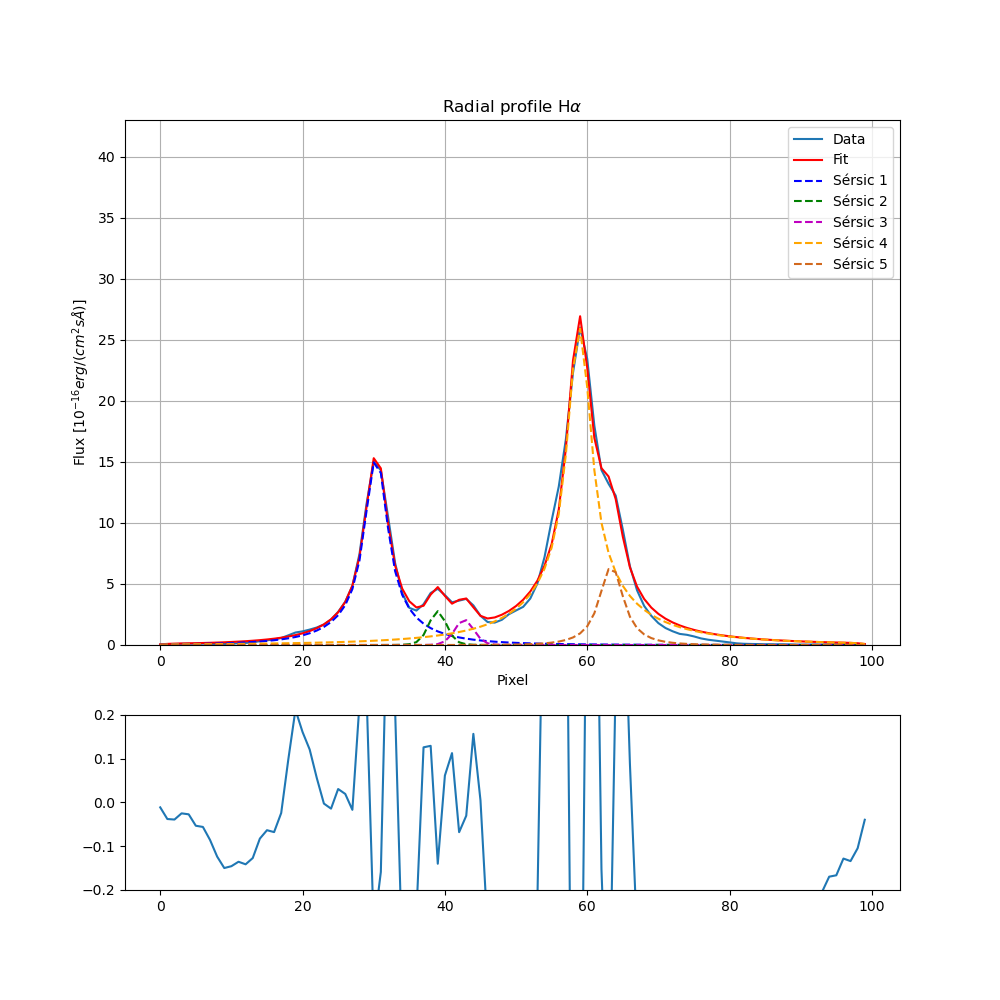

In [12]:
save_params_diff(best_params, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha_diff", output_prefix="fit")

plot_diff(x_axes, best_params, radial_profile_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_diff')

In [13]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HA, covariance_HA = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes, radial_profile_HA, p0=result.x, 
                                           sigma = real_errors_HA)#, bounds = bounds_list, maxfev= 10000)

print("Optimize parameters with curve fit:")

chi2_reduced_HA, dof_HA, chi2_HA = save_params(params_curve_HA, covariance_HA, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_20856\637918482.py:11: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_20856\637918482.py:24: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=1.1158, r_e=9.1314, n=1.8545, x_0=30.2768
Sérsic 2: I_e=2.5999, r_e=1.3614, n=0.0786, x_0=38.8987
Sérsic 3: I_e=0.7695, r_e=2.3164, n=1.0662, x_0=42.8431
Sérsic 4: I_e=3.6874, r_e=7.1782, n=1.3262, x_0=58.9702
Sérsic 5: I_e=0.6489, r_e=3.8326, n=1.7652, x_0=64.0178
[1.08360763e-01 4.61419174e-01 1.56916735e-01 1.25692349e-02
 4.53534958e+01 1.13167067e+01 2.40342330e+00 1.95083028e-01
 6.36275952e-01 1.02674760e+00 6.73101818e-01 2.48123524e-01
 3.20129610e-01 3.71183642e-01 6.52470951e-02 1.13607558e-01
 6.38801215e-01 2.33407491e+00 8.07383372e-01 2.23974808e-01]
2.052744610977622


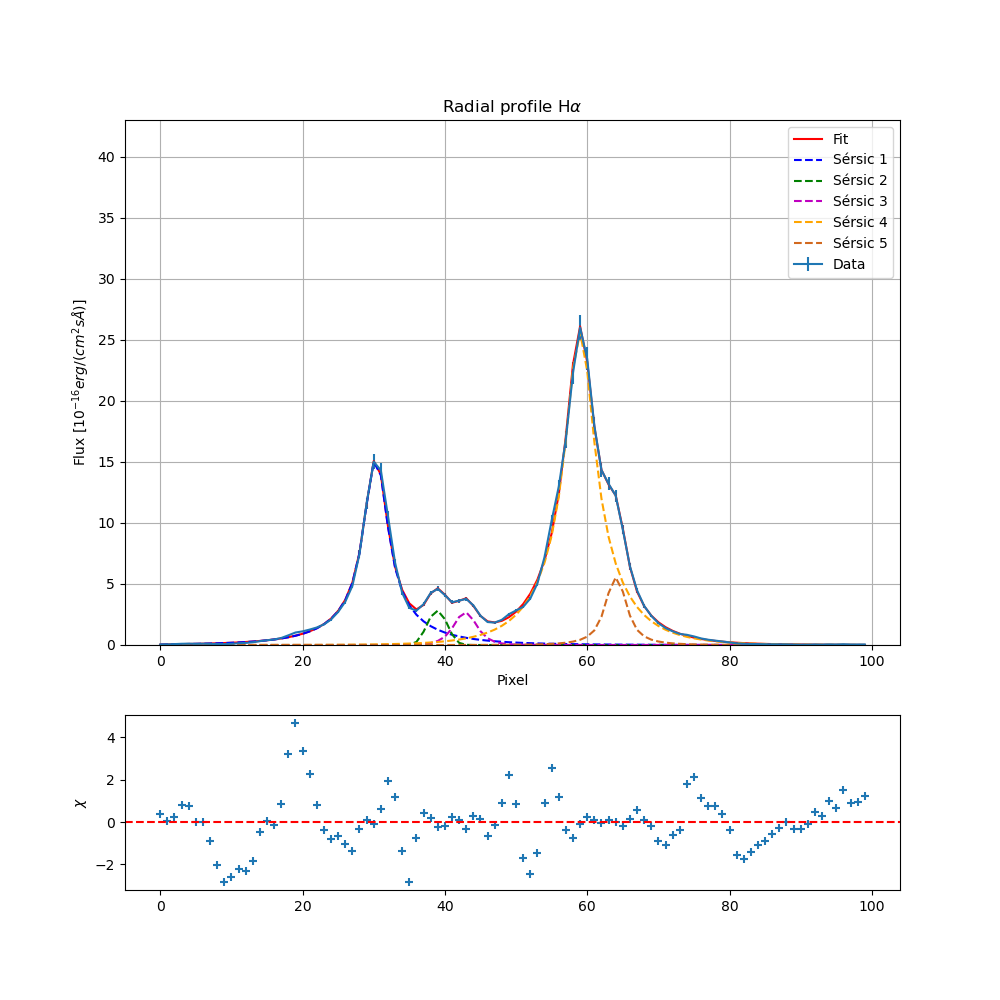

In [14]:
plot_curve(x_axes, params_curve_HA, radial_profile_HA, real_errors_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_curve')

In [81]:
fit_HA = pd.read_csv("Halpha_fit.csv", index_col=0)
x_0_HA = fit_HA.iloc[3].values
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 10),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-seeing[-1]/2, x_0_HA[0]+seeing[-1]/2),   # x_0: circa la posizione di Halpha

    (0, 5),
    (0, 3),
    (0.1, 10),
    (40.5, 42),

    (0, 5),
    (0, 3),
    (0.1, 10),
    (x_0_HA[2]-seeing[-1]/2, x_0_HA[2]+seeing[-1]/2),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-seeing[-1]/2, x_0_HA[3]+seeing[-1]/2),

    (0, 20),
    (0, 5),
    (0.1, 10),
    (x_0_HA[4]-seeing[-1]/2, x_0_HA[4]+seeing[-1]/2),
]

In [54]:
x_0_HA[1]+seeing[-1]/2

40.0892

## H$\beta$

Text(0.5, 1.0, 'H$\\beta$')

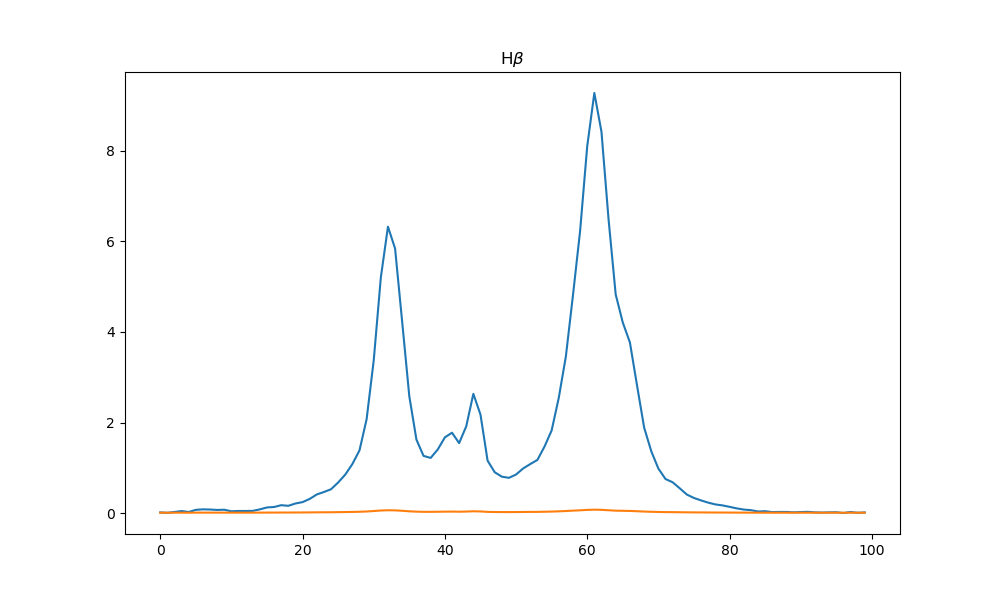

In [55]:
mask_HB = (wv > l_HB-8)*(wv < l_HB+8)
image_HB = image_cut[:, mask_HB] 
image_error_HB = image_error_cut[:, mask_HB]
radial_profile_HB = np.sum(image_HB, axis = 1)
radial_profile_error_HB = np.sqrt(np.sum(image_error_HB**2, axis = 1))
real_errors_HB = np.sqrt(radial_profile_error_HB**2+(sky_err[2])**2+(0.04*radial_profile_HB)**2)

plt.figure(figsize=(10, 6))
x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile_HB)
plt.plot(x_axes, radial_profile_error_HB)
plt.title(r'H$\beta$')

In [56]:
# Bounds:
bounds = bounds

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HB, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 3081.7171540705062
differential_evolution step 2: f(x)= 2813.333273077066
differential_evolution step 3: f(x)= 1777.602595547058
differential_evolution step 4: f(x)= 172.16803271253423
differential_evolution step 5: f(x)= 172.16803271253423
differential_evolution step 6: f(x)= 172.16803271253423
differential_evolution step 7: f(x)= 172.16803271253423
differential_evolution step 8: f(x)= 172.16803271253423
differential_evolution step 9: f(x)= 172.16803271253423
differential_evolution step 10: f(x)= 172.16803271253423
differential_evolution step 11: f(x)= 95.12166648020764
differential_evolution step 12: f(x)= 95.12166648020764
differential_evolution step 13: f(x)= 95.12166648020764
differential_evolution step 14: f(x)= 95.12166648020764
differential_evolution step 15: f(x)= 95.12166648020764
differential_evolution step 16: f(x)= 95.12166648020764
differential_evolution step 17: f(x)= 95.12166648020764
differential_evolution step 18: f(x)= 95.12166648

Sérsic 1: I_e=0.9934, r_e=4.9382, n=1.3287, x_0=31.4673
Sérsic 2: I_e=0.2995, r_e=3.0000, n=0.9762, x_0=40.5000
Sérsic 3: I_e=0.1423, r_e=3.0000, n=2.6523, x_0=44.0336
Sérsic 4: I_e=0.3336, r_e=15.6071, n=2.0199, x_0=60.1607
Sérsic 5: I_e=1.4570, r_e=3.7218, n=0.6878, x_0=62.8273


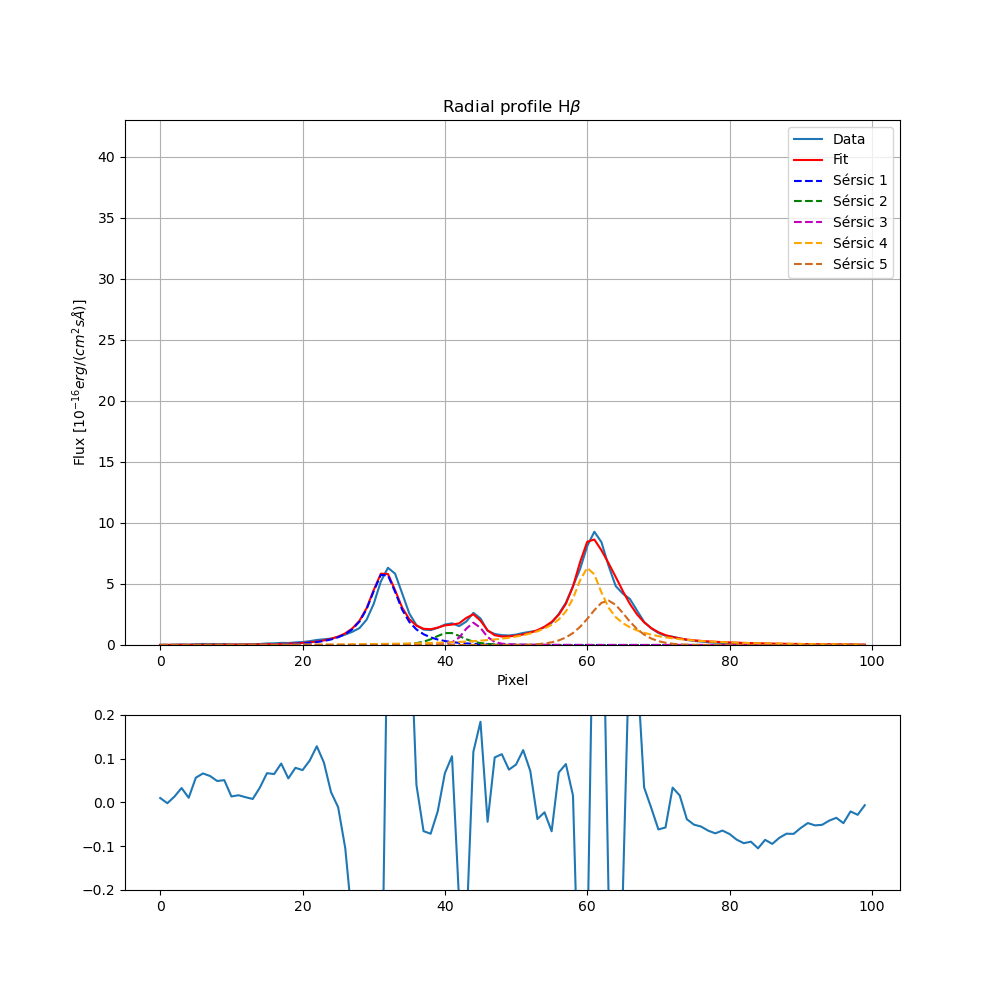

In [57]:
save_params_diff(best_params, radial_profile_HB, real_errors_HB, sigmas[1],
    x_axes, n_component, line_name="HBeta", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_diff')

In [64]:
#bounds = bounds
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HB, covariance_HB = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), 
                                           x_axes, radial_profile_HB, p0=result.x, sigma = real_errors_HB, maxfev = 10000)  #, bounds = bounds_list, maxfev = 10000)

print("Optimize parameters with curve fit:")
chi2_reduced_HB, dof_HB, chi2_HB = save_params(params_curve_HB, covariance_HB, radial_profile_HB, real_errors_HB, sigmas[1],
    x_axes, n_component, line_name="Hbeta", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_20856\637918482.py:11: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_20856\637918482.py:24: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.3202, r_e=10.5456, n=2.2541, x_0=32.1803
Sérsic 2: I_e=0.5025, r_e=0.3511, n=2.2259, x_0=40.3031
Sérsic 3: I_e=0.0418, r_e=9.3480, n=3.4050, x_0=44.0413
Sérsic 4: I_e=1.0796, r_e=8.0792, n=1.3298, x_0=61.0041
Sérsic 5: I_e=0.9315, r_e=4.8684, n=0.0713, x_0=62.6133
[5.62698982e-02 1.47329905e+00 1.43004269e-01 3.65151949e-02
 7.68495710e+01 2.53224501e+01 1.84792803e+02 1.11877239e-01
 2.93882857e-01 4.15904134e+01 9.02085509e+00 6.52465655e-04
 9.56289271e-02 4.15100216e-01 5.02524864e-02 1.03038076e-01
 1.60056757e+00 2.58766925e+00 1.55380181e-01 1.94044937e-01]
0.7342856329284911


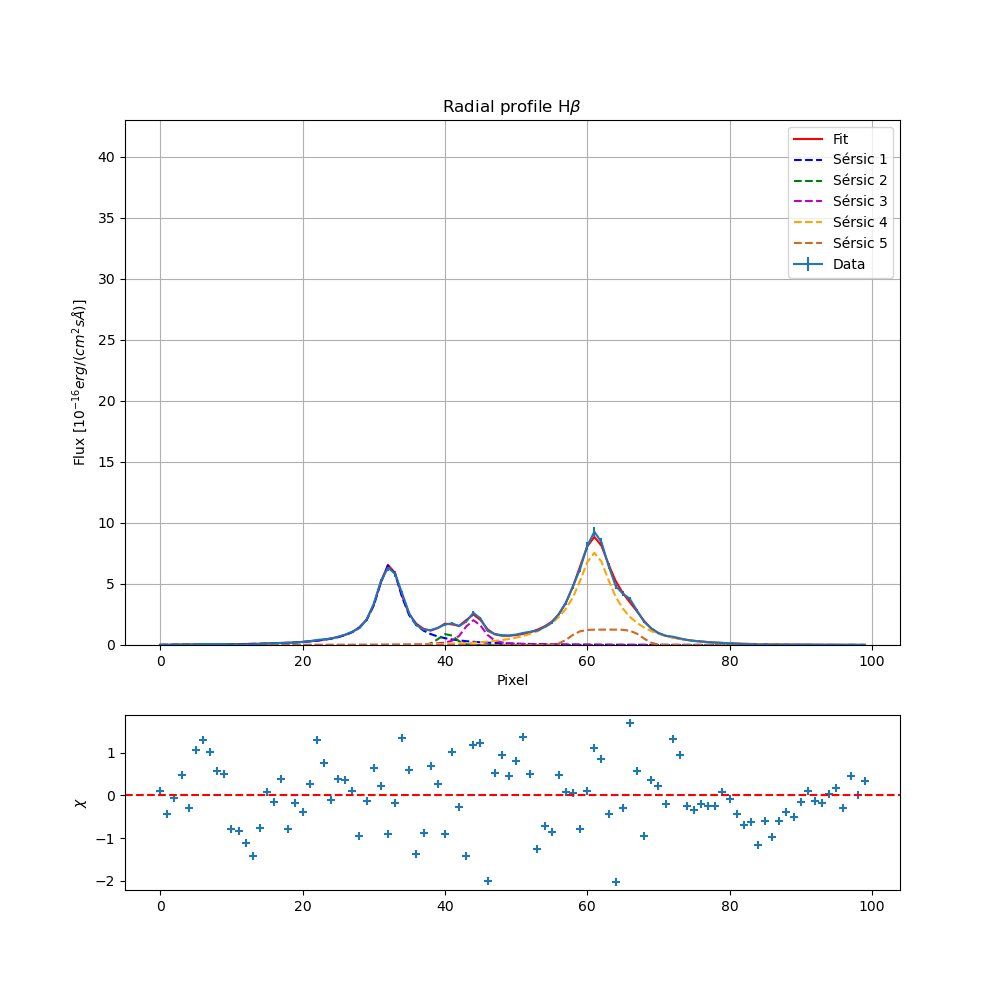

In [65]:
# Plots:
plot_curve(x_axes, params_curve_HB, radial_profile_HB, real_errors_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_curve')

## [NII]

Text(0.5, 1.0, '[NII]')

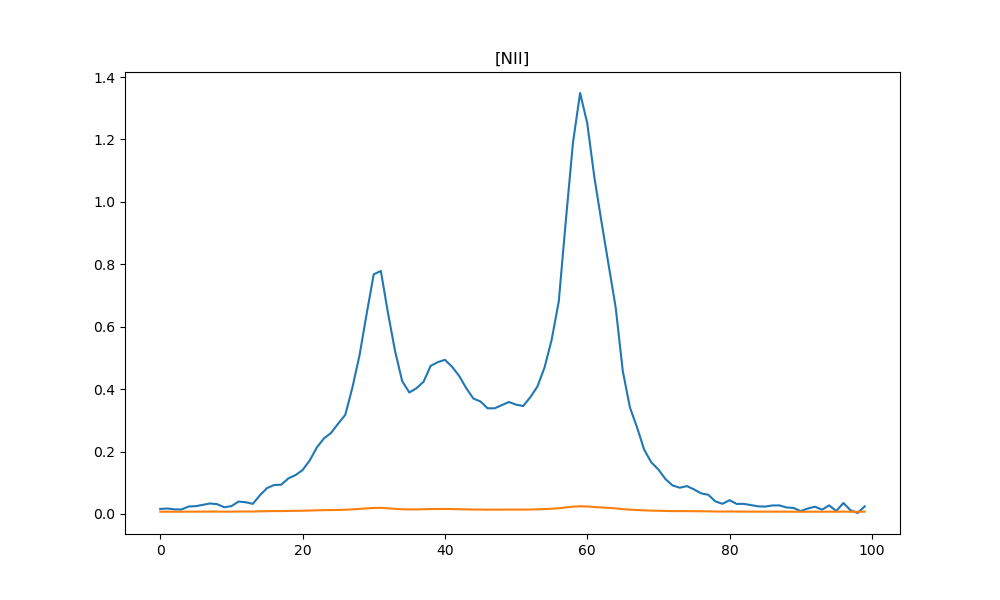

In [67]:
mask_NII = (wv > l_NII-8)*(wv < l_NII+8)
image_NII = image_cut[:, mask_NII]
image_error_NII = image_error_cut[:, mask_NII]
radial_profile_NII = np.sum(image_NII, axis = 1)
radial_profile_error_NII = np.sqrt(np.sum(image_error_NII**2, axis = 1))
real_errors_NII = np.sqrt(radial_profile_error_NII**2+(sky_err[2])**2+(0.04*radial_profile_NII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_NII)
plt.plot(x_axes, radial_profile_error_NII)
plt.title(r'[NII]')

In [68]:
# Bounds:
bounds = bounds
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_NII, sigmas[2])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 3193.3904042826202
differential_evolution step 2: f(x)= 3193.3904042826202
differential_evolution step 3: f(x)= 1746.5298951864738
differential_evolution step 4: f(x)= 1746.5298951864738
differential_evolution step 5: f(x)= 1213.8937317621546
differential_evolution step 6: f(x)= 392.48174913074087
differential_evolution step 7: f(x)= 392.48174913074087
differential_evolution step 8: f(x)= 392.48174913074087
differential_evolution step 9: f(x)= 392.48174913074087
differential_evolution step 10: f(x)= 392.48174913074087
differential_evolution step 11: f(x)= 392.48174913074087
differential_evolution step 12: f(x)= 392.48174913074087
differential_evolution step 13: f(x)= 67.33431242874528
differential_evolution step 14: f(x)= 67.33431242874528
differential_evolution step 15: f(x)= 44.17378846890259
differential_evolution step 16: f(x)= 44.17378846890259
differential_evolution step 17: f(x)= 44.17378846890259
differential_evolution step 18: f(x)= 44.1737

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_20856\637918482.py:11: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with differential_evolution:
Sérsic 1: I_e=0.1313, r_e=10.0000, n=1.1068, x_0=30.5637
Sérsic 2: I_e=0.2162, r_e=3.0000, n=0.2673, x_0=41.5143
Sérsic 3: I_e=1.0932, r_e=0.0000, n=3.9238, x_0=41.8710
Sérsic 4: I_e=0.1083, r_e=14.9184, n=1.6334, x_0=58.9707
Sérsic 5: I_e=0.2305, r_e=1.5096, n=0.1183, x_0=62.8273
Chi quadro minimo: 0.09296576646527273
False


Sérsic 1: I_e=0.1313, r_e=10.0000, n=1.1068, x_0=30.5637
Sérsic 2: I_e=0.2162, r_e=3.0000, n=0.2673, x_0=41.5143
Sérsic 3: I_e=1.0932, r_e=0.0000, n=3.9238, x_0=41.8710
Sérsic 4: I_e=0.1083, r_e=14.9184, n=1.6334, x_0=58.9707
Sérsic 5: I_e=0.2305, r_e=1.5096, n=0.1183, x_0=62.8273


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_20856\637918482.py:11: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


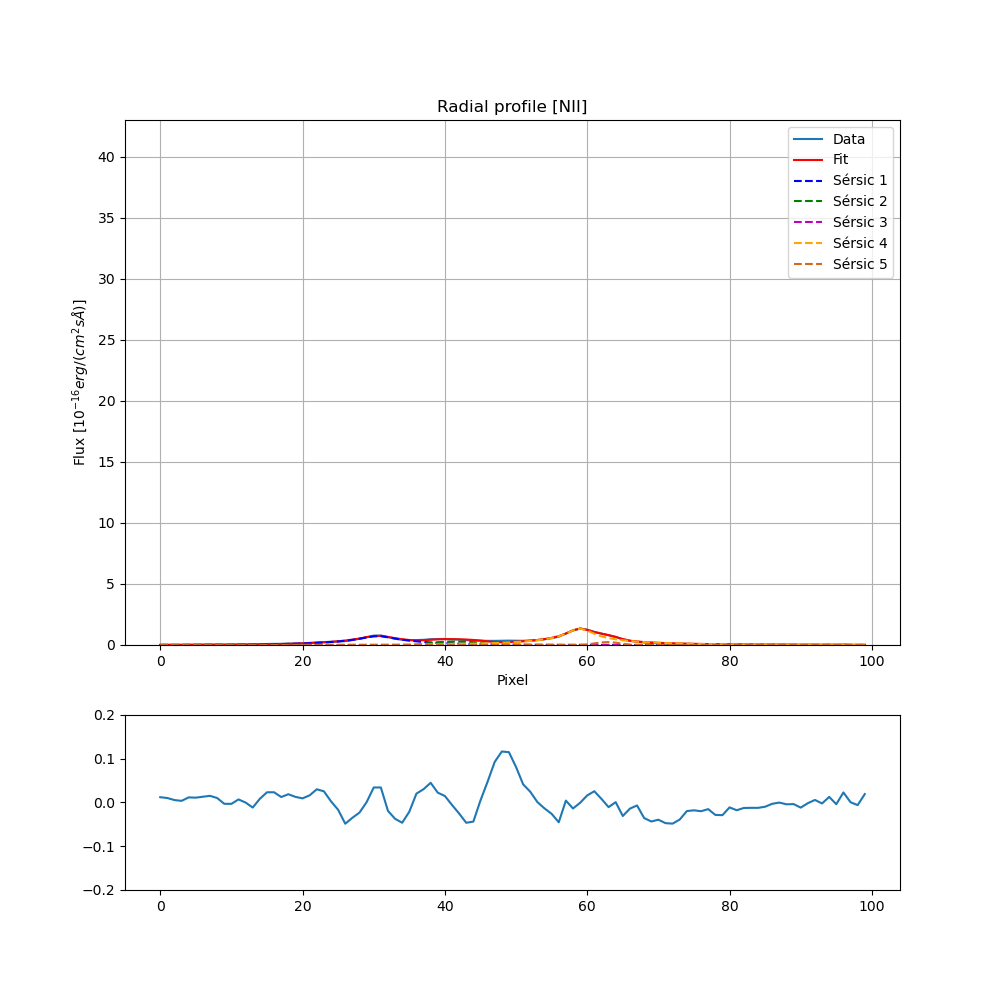

In [69]:
save_params_diff(best_params, radial_profile_NII, real_errors_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_diff')

In [70]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_NII, covariance_NII = curve_fit(lambda x, *params: model_convolved(x, sigmas[2], *params), x_axes, radial_profile_NII, 
                                             p0=result.x, sigma = real_errors_NII)#, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_NII, dof_NII, chi2_NII = save_params(params_curve_NII, covariance_NII, radial_profile_NII, real_errors_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_20856\637918482.py:11: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_20856\637918482.py:11: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_20856\637918482.py:24: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.0427, r_e=15.6767, n=1.7906, x_0=30.2026
Sérsic 2: I_e=0.0589, r_e=17.6800, n=1.1091, x_0=40.5669
Sérsic 3: I_e=1.0932, r_e=0.0000, n=3.9238, x_0=41.8710
Sérsic 4: I_e=0.0879, r_e=13.1427, n=1.6588, x_0=58.6838
Sérsic 5: I_e=0.2266, r_e=2.6029, n=0.4709, x_0=61.8571
[inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf
 inf inf]
0.2227856007972023


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_20856\738905611.py:3: OptimizeWarning: Covariance of the parameters could not be estimated
  params_curve_NII, covariance_NII = curve_fit(lambda x, *params: model_convolved(x, sigmas[2], *params), x_axes, radial_profile_NII,


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_20856\637918482.py:11: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


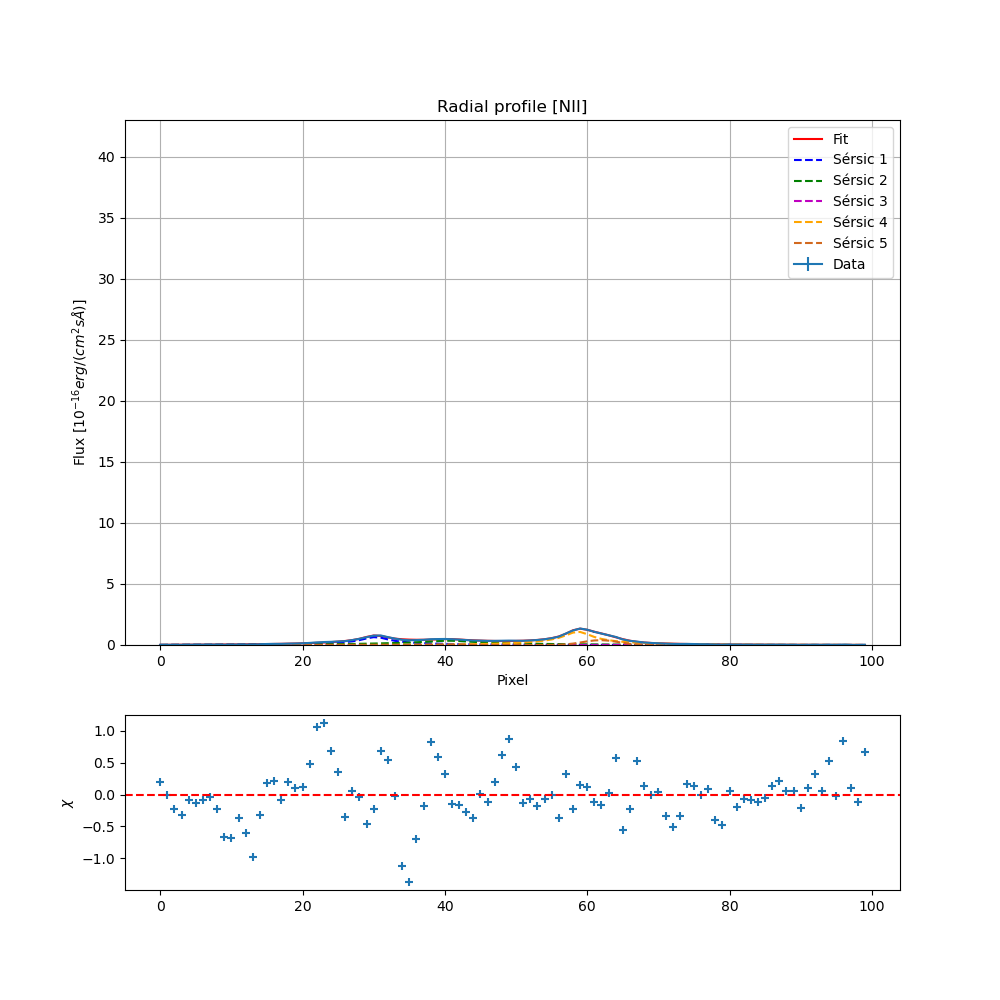

In [71]:
plot_curve(x_axes, params_curve_NII, radial_profile_NII, real_errors_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_curve')

## [SII]

Text(0.5, 1.0, '[SII]')

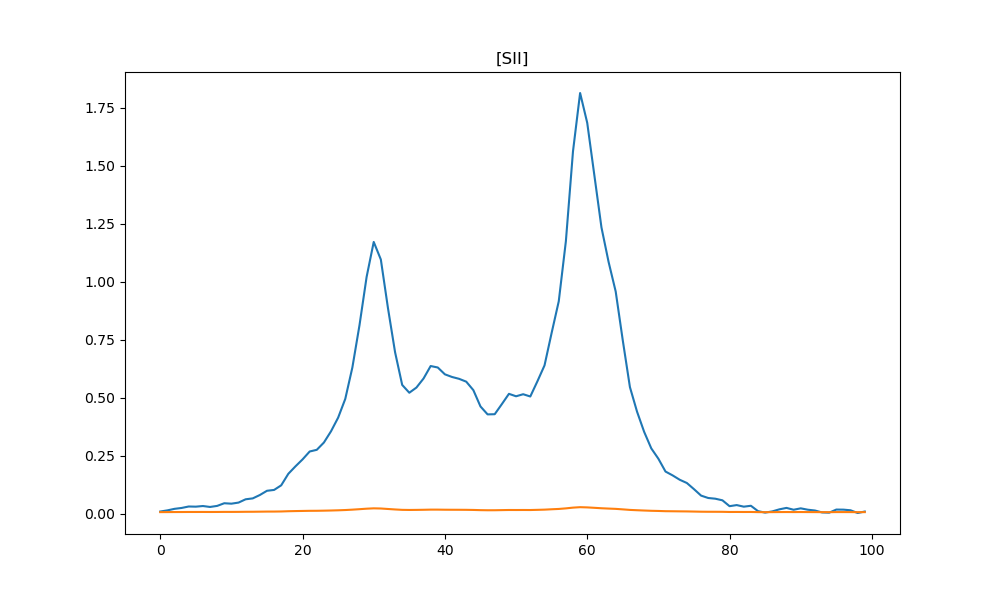

In [72]:
mask_SII = (wv > l_SII-8)*(wv < l_SII+8)
image_SII = image_cut[:, mask_SII] 
image_error_SII = image_error_cut[:, mask_SII]
radial_profile_SII = np.sum(image_SII, axis = 1)
radial_profile_error_SII = np.sqrt(np.sum(image_error_SII**2, axis = 1))
real_errors_SII = np.sqrt(radial_profile_error_SII**2+(sky_err[2])**2+(0.04*radial_profile_SII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_SII)
plt.plot(x_axes, radial_profile_error_SII)
plt.title(r'[SII]')

In [77]:
# Bounds:
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 10),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-seeing[-1]/2, x_0_HA[0]+seeing[-1]/2),   # x_0: circa la posizione di Halpha

    (0, 5),
    (0, 3),
    (0.1, 10),
    (x_0_HA[1]-seeing[-1]/2, x_0_HA[1]+seeing[-1]/2),

    (0, 5),
    (0, 3),
    (0.1, 10),
    (x_0_HA[2]-seeing[-1]/2, x_0_HA[2]+seeing[-1]/2),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-seeing[-1]/2, x_0_HA[3]+seeing[-1]/2),

    (0, 20),
    (0, 5),
    (0.1, 10),
    (x_0_HA[4]-seeing[-1]/2, x_0_HA[4]+seeing[-1]/2),
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_SII, sigmas[3])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 4832.3534582042075
differential_evolution step 2: f(x)= 2931.094781825727
differential_evolution step 3: f(x)= 250.9389423538797
differential_evolution step 4: f(x)= 154.06130387851582
differential_evolution step 5: f(x)= 154.06130387851582
differential_evolution step 6: f(x)= 114.77250895405814
differential_evolution step 7: f(x)= 83.71247786815853
differential_evolution step 8: f(x)= 83.71247786815853
differential_evolution step 9: f(x)= 55.368505171649524
differential_evolution step 10: f(x)= 55.368505171649524
differential_evolution step 11: f(x)= 55.368505171649524
differential_evolution step 12: f(x)= 55.368505171649524
differential_evolution step 13: f(x)= 31.106921425121616
differential_evolution step 14: f(x)= 31.106921425121616
differential_evolution step 15: f(x)= 31.106921425121616
differential_evolution step 16: f(x)= 31.106921425121616
differential_evolution step 17: f(x)= 31.106921425121616
differential_evolution step 18: f(x)= 31.106

Sérsic 1: I_e=0.1706, r_e=9.9870, n=1.2292, x_0=30.1331
Sérsic 2: I_e=0.2246, r_e=1.9278, n=0.2966, x_0=38.8738
Sérsic 3: I_e=0.1795, r_e=2.9873, n=0.4462, x_0=44.0336
Sérsic 4: I_e=0.2328, r_e=11.4368, n=1.3220, x_0=59.3483
Sérsic 5: I_e=12.3185, r_e=0.0087, n=7.7521, x_0=63.7151


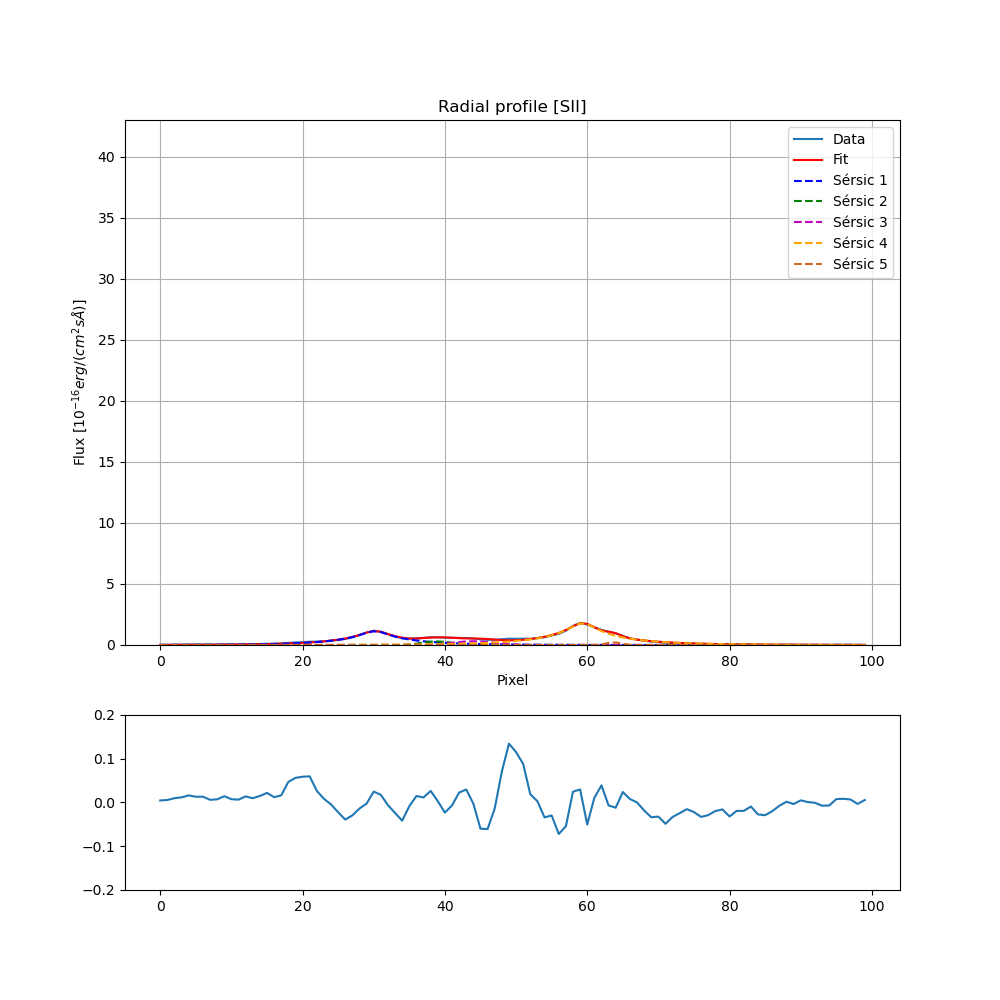

In [78]:
save_params_diff(best_params, radial_profile_SII, real_errors_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_diff')

In [79]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_SII, covariance_SII = curve_fit(lambda x, *params: model_convolved(x, sigmas[3], *params), x_axes, 
                                             radial_profile_SII, p0=result.x, sigma = real_errors_SII, bounds = bounds_list)

print("Optimize parameters with curve fit:")
chi2_reduced_SII, dof_SII, chi2_SII = save_params(params_curve_SII, covariance_SII, radial_profile_SII, real_errors_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.1785, r_e=10.0000, n=1.1849, x_0=30.1167
Sérsic 2: I_e=0.2237, r_e=2.0097, n=0.2878, x_0=38.8947
Sérsic 3: I_e=0.1892, r_e=3.0000, n=0.3942, x_0=44.0336
Sérsic 4: I_e=0.2679, r_e=10.3369, n=1.2183, x_0=59.3240
Sérsic 5: I_e=12.2958, r_e=0.0019, n=7.7899, x_0=63.7211
[2.32092658e-02 9.00680787e-01 9.31862470e-02 1.07816292e-01
 1.36600533e-01 6.17819964e-01 3.54457330e-01 1.35866566e+00
 9.28352388e-02 1.18974037e+00 2.65967099e-01 2.04939621e+00
 3.02071313e-02 7.36424876e-01 7.86209698e-02 1.07729336e-01
 6.63568711e+06 4.59480860e+02 8.29869062e+05 5.93692032e+01]
0.8472757211618893


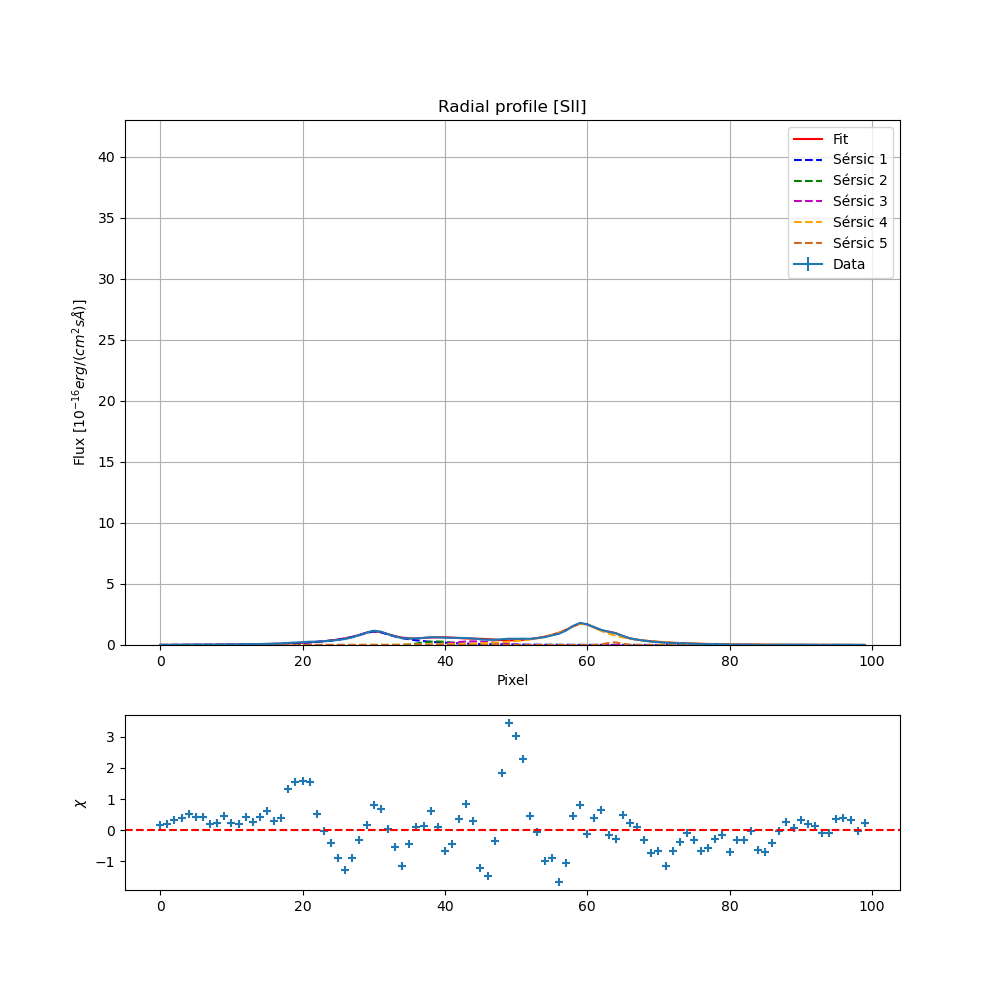

In [80]:
# Plots:
plot_curve(x_axes, params_curve_SII, radial_profile_SII, real_errors_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_curve')

## [OIII]

Text(0.5, 1.0, '[OIII]')

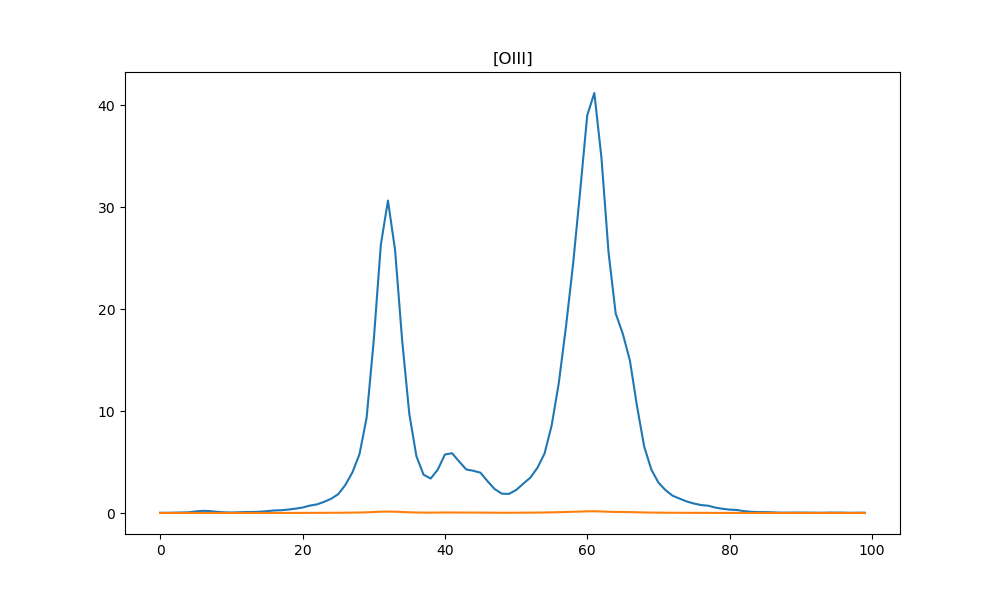

In [83]:
mask_OIII = (wv > l_OIII-8)*(wv < l_OIII+8)
image_OIII = image_cut[:, mask_OIII] 
image_error_OIII = image_error_cut[:, mask_OIII]
radial_profile_OIII = np.sum(image_OIII, axis = 1)
radial_profile_error_OIII = np.sqrt(np.sum(image_error_OIII**2, axis = 1))
real_errors_OIII = np.sqrt(radial_profile_error_OIII**2+(sky_err[2])**2+(0.04*radial_profile_OIII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_OIII)
plt.plot(x_axes, radial_profile_error_OIII)
plt.title(r'[OIII]')

In [84]:
# Bounds:
bounds =[
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 10),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-seeing[-1]/2, x_0_HA[0]+seeing[-1]/2),   # x_0: circa la posizione di Halpha

    (0, 5),
    (0, 3),
    (0.1, 10),
    (40, 41),

    (0, 5),
    (0, 3),
    (0.1, 10),
    (x_0_HA[2]-seeing[-1]/2, x_0_HA[2]+seeing[-1]/2),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-seeing[-1]/2, x_0_HA[3]+seeing[-1]/2),

    (0, 20),
    (0, 5),
    (0.1, 10),
    (x_0_HA[4]-seeing[-1]/2, x_0_HA[4]+seeing[-1]/2),
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_OIII, sigmas[4])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 4121.76170436412
differential_evolution step 2: f(x)= 4121.76170436412
differential_evolution step 3: f(x)= 4121.76170436412
differential_evolution step 4: f(x)= 3106.6814107154696
differential_evolution step 5: f(x)= 2376.5115960541357
differential_evolution step 6: f(x)= 2376.5115960541357
differential_evolution step 7: f(x)= 2321.9277271757956
differential_evolution step 8: f(x)= 2298.6254756659196
differential_evolution step 9: f(x)= 1504.3941198780221
differential_evolution step 10: f(x)= 1072.5503406674031
differential_evolution step 11: f(x)= 1072.5503406674031
differential_evolution step 12: f(x)= 1072.5503406674031
differential_evolution step 13: f(x)= 1072.5503406674031
differential_evolution step 14: f(x)= 1072.5503406674031
differential_evolution step 15: f(x)= 1072.5503406674031
differential_evolution step 16: f(x)= 1072.5503406674031
differential_evolution step 17: f(x)= 1072.5503406674031
differential_evolution step 18: f(x)= 965.8594

Sérsic 1: I_e=7.3288, r_e=3.1851, n=1.1198, x_0=31.4673
Sérsic 2: I_e=1.4904, r_e=3.0000, n=0.6680, x_0=40.0000
Sérsic 3: I_e=2.1569, r_e=2.9595, n=0.1000, x_0=43.5313
Sérsic 4: I_e=6.5048, r_e=6.0798, n=1.2303, x_0=60.1607
Sérsic 5: I_e=6.5015, r_e=3.1195, n=0.1000, x_0=63.9323


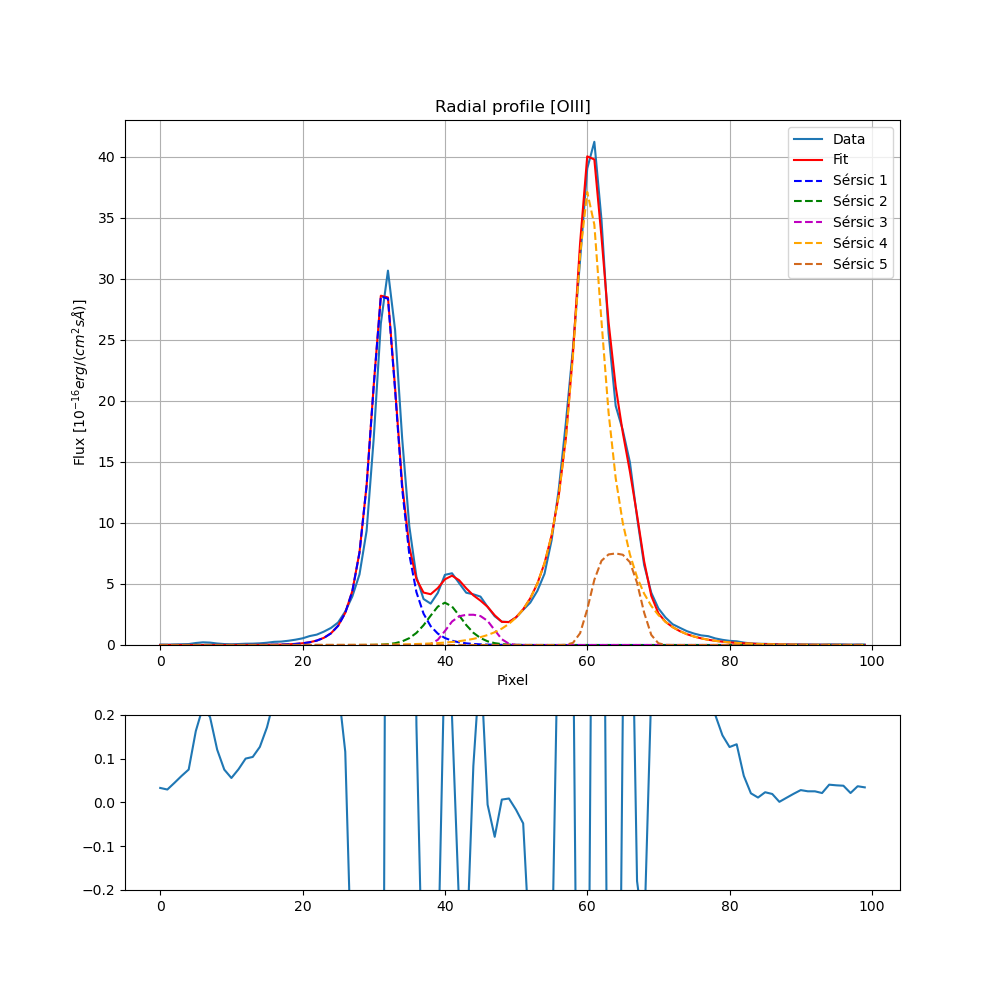

In [85]:
save_params_diff(best_params, radial_profile_OIII, real_errors_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_diff')

In [88]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_OIII, covariance_OIII = curve_fit(lambda x, *params: model_convolved(x, sigmas[4], *params), x_axes, radial_profile_OIII, 
                                               p0=result.x, sigma = real_errors_OIII)#, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_OIII, dof_OIII, chi2_OIII = save_params(params_curve_OIII, covariance_OIII, radial_profile_OIII, real_errors_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=2.6187, r_e=5.7810, n=2.0166, x_0=31.9717
Sérsic 2: I_e=4.4149, r_e=0.6211, n=0.0717, x_0=40.1921
Sérsic 3: I_e=2.7394, r_e=2.6477, n=0.1105, x_0=43.2375
Sérsic 4: I_e=6.1639, r_e=6.3856, n=1.3993, x_0=60.5687
Sérsic 5: I_e=4.1213, r_e=1.1411, n=0.6663, x_0=65.6182
[1.90346643e-01 2.03964796e-01 8.12200297e-02 4.04974794e-02
 4.32627911e+03 2.05762226e+02 9.87803642e+01 3.38274142e+00
 5.78301132e+00 4.07070610e+01 1.37769155e+00 3.55327622e+01
 3.47195442e-01 1.27090070e-01 4.95427944e-02 7.22273224e-02
 4.21919093e+00 4.31928919e-01 9.92033951e-01 2.18129622e-01]
1.9358692894362766


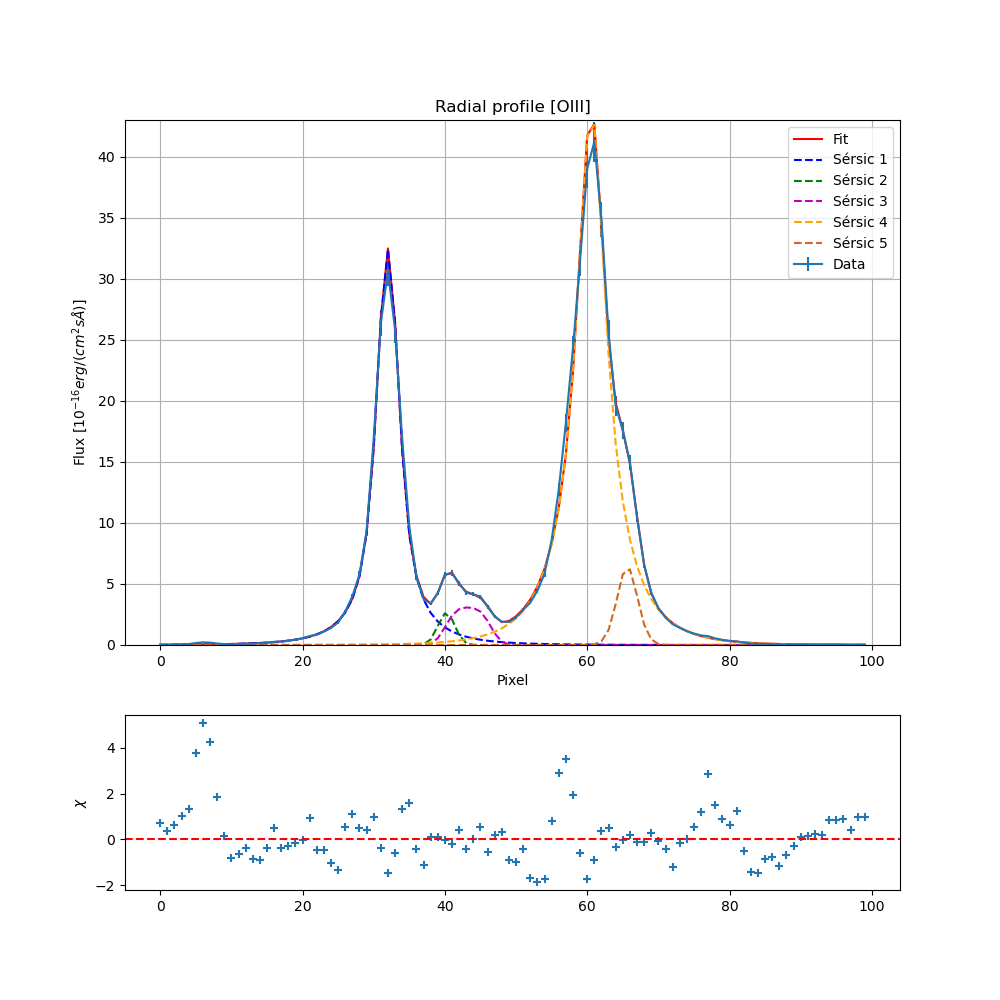

In [89]:
plot_curve(x_axes, params_curve_OIII, radial_profile_OIII, real_errors_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_curve')

In [90]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)

## Continuum 1

Text(0.5, 1.0, 'Continuum 1')

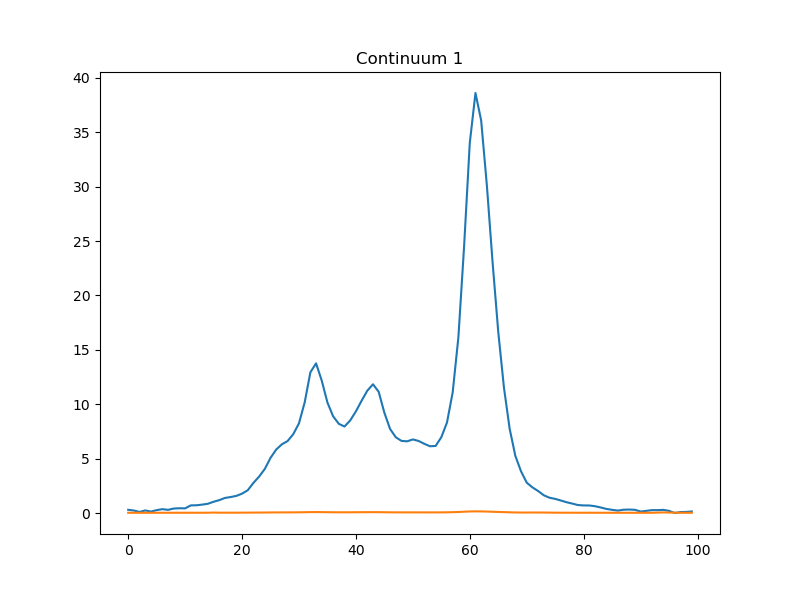

In [91]:
mask_continuum_1 = (wv > 4500)*(wv < 4800)
image_continuum_1 = image_cut[:, mask_continuum_1]
image_error_continuum_1 = image_error_cut[:, mask_continuum_1]
radial_profile_continuum_1 = np.sum(image_continuum_1, axis = 1)
radial_profile_error_continuum_1 = np.sqrt(np.sum(image_error_continuum_1**2, axis = 1))
real_errors_c1 = np.sqrt(radial_profile_error_continuum_1**2+(sky_err[2])**2+(0.04*radial_profile_continuum_1)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_1)
plt.plot(x_axes, radial_profile_error_continuum_1)
plt.title(r'Continuum 1')

In [92]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_1, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 838.5022144705941
differential_evolution step 2: f(x)= 838.5022144705941
differential_evolution step 3: f(x)= 688.3568136527738
differential_evolution step 4: f(x)= 504.5093768798496
differential_evolution step 5: f(x)= 504.5093768798496
differential_evolution step 6: f(x)= 504.5093768798496
differential_evolution step 7: f(x)= 360.83558939451575
differential_evolution step 8: f(x)= 360.83558939451575
differential_evolution step 9: f(x)= 360.83558939451575
differential_evolution step 10: f(x)= 360.83558939451575
differential_evolution step 11: f(x)= 360.83558939451575
differential_evolution step 12: f(x)= 360.83558939451575
differential_evolution step 13: f(x)= 360.83558939451575
differential_evolution step 14: f(x)= 360.83558939451575
differential_evolution step 15: f(x)= 360.83558939451575
differential_evolution step 16: f(x)= 360.83558939451575
differential_evolution step 17: f(x)= 360.83558939451575
differential_evolution step 18: f(x)= 360.8355

In [93]:
def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 30)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 30)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

Sérsic 1: I_e=0.8803, r_e=16.9456, n=1.6118, x_0=32.6261
Sérsic 2: I_e=0.9962, r_e=13.5779, n=0.1016, x_0=37.7611
Sérsic 3: I_e=0.7573, r_e=13.9864, n=1.5388, x_0=42.9737
Sérsic 4: I_e=0.9903, r_e=14.5186, n=2.5832, x_0=60.5913
Sérsic 5: I_e=0.9995, r_e=7.3358, n=2.1787, x_0=63.1629


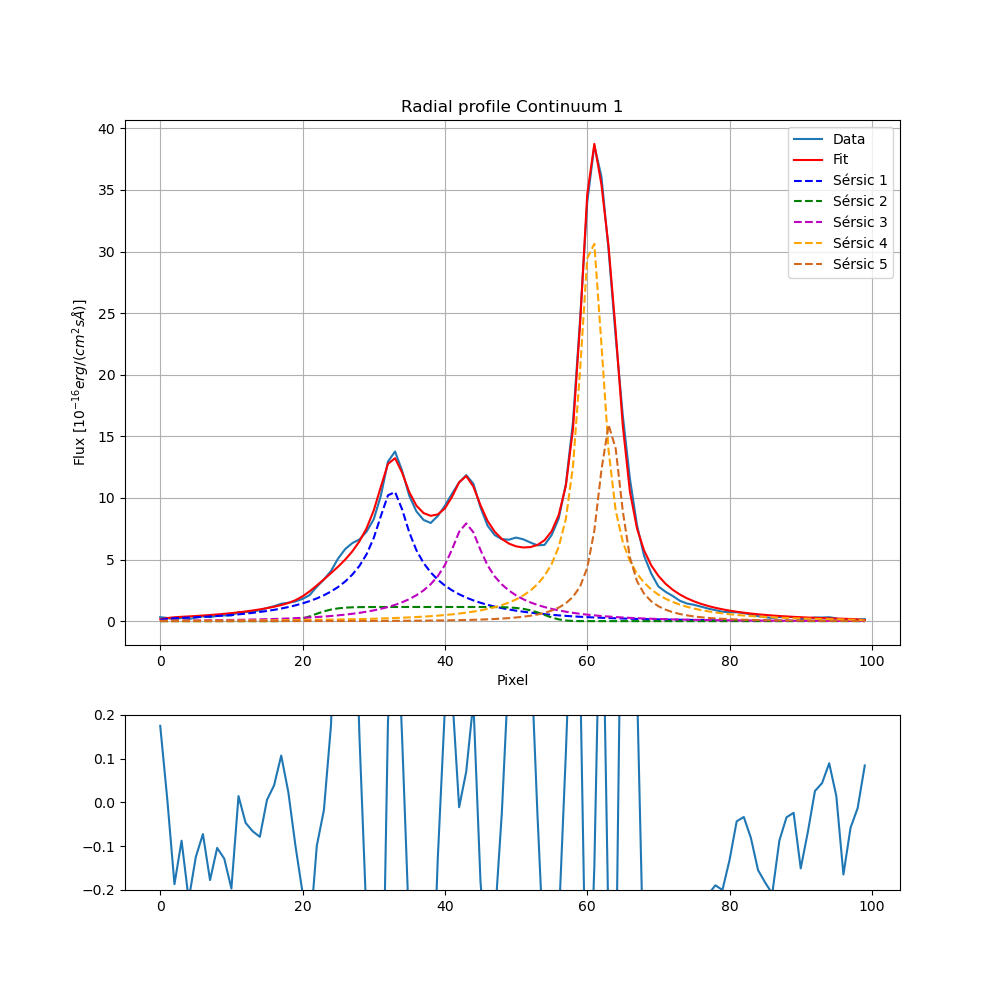

In [94]:
save_params_diff(best_params, radial_profile_continuum_1, real_errors_c1, sigmas[1],
    x_axes, n_component, line_name="Continuum_1", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_diff')

In [95]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))

params_curve_continuum_1, covariance_continuum_1 = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), x_axes,
                                                             radial_profile_continuum_1, p0=result.x, sigma = real_errors_c1, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_1, dof_continuum_1, chi2_continuum_1 = save_params(params_curve_continuum_1, covariance_continuum_1, 
                                                                          radial_profile_continuum_1, real_errors_c1, sigmas[1],
                                                                          x_axes, n_component, line_name="Continuum_1", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.9960, r_e=14.6612, n=1.4877, x_0=32.4554
Sérsic 2: I_e=0.9998, r_e=14.1692, n=0.1000, x_0=38.8179
Sérsic 3: I_e=0.9020, r_e=14.6679, n=1.4010, x_0=43.0017
Sérsic 4: I_e=0.9925, r_e=13.3592, n=2.7294, x_0=60.5231
Sérsic 5: I_e=0.9941, r_e=5.8754, n=2.3562, x_0=63.5892
[ 0.48330796  9.57421266  0.36563567  0.15357188  0.81852864  5.45016545
  0.09812759  2.37866713  1.03724502 22.59339461  0.77836042  0.23056921
  0.87536971  8.95466451  0.7845625   0.18148841  1.24374495  6.25208397
  1.02945021  0.27068762]
2.417501938228381


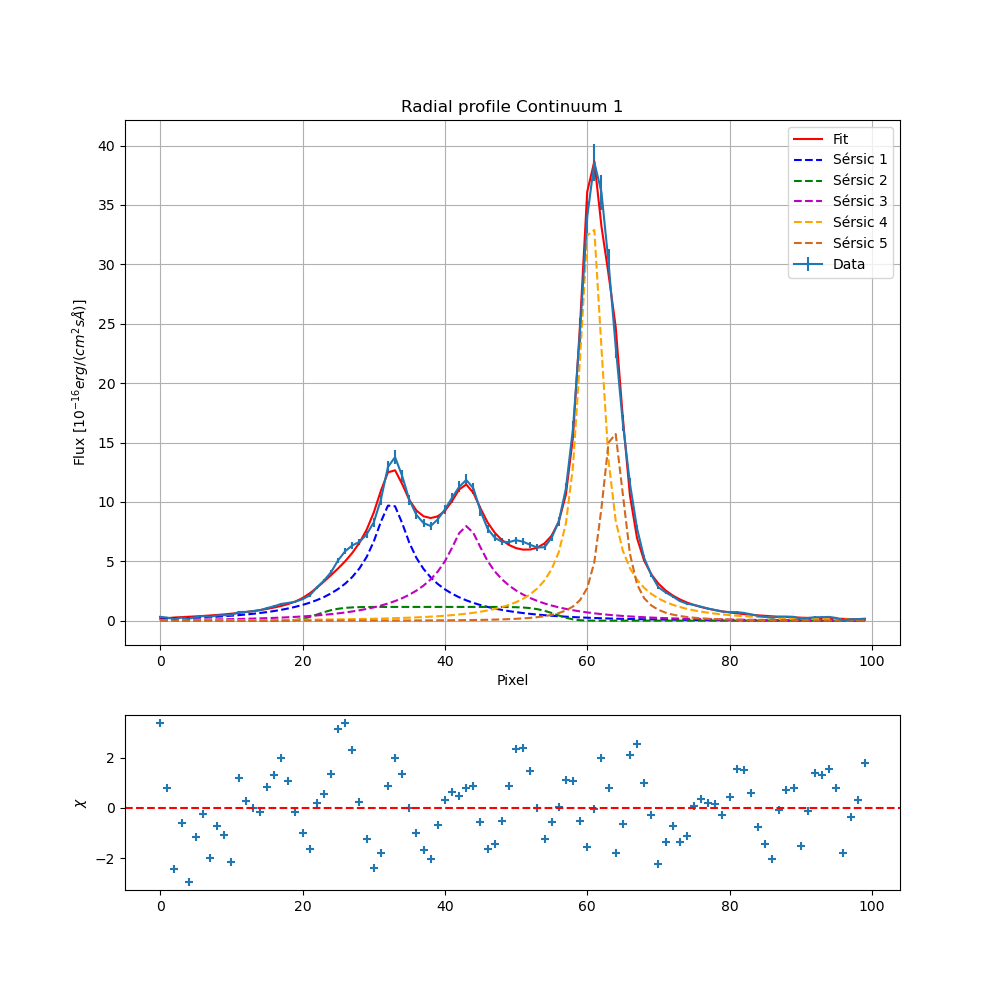

In [96]:
# Plots:
plot_curve(x_axes, params_curve_continuum_1, radial_profile_continuum_1, real_errors_c1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_curve')

## Continuum 2 

Text(0.5, 1.0, 'Continuum 2')

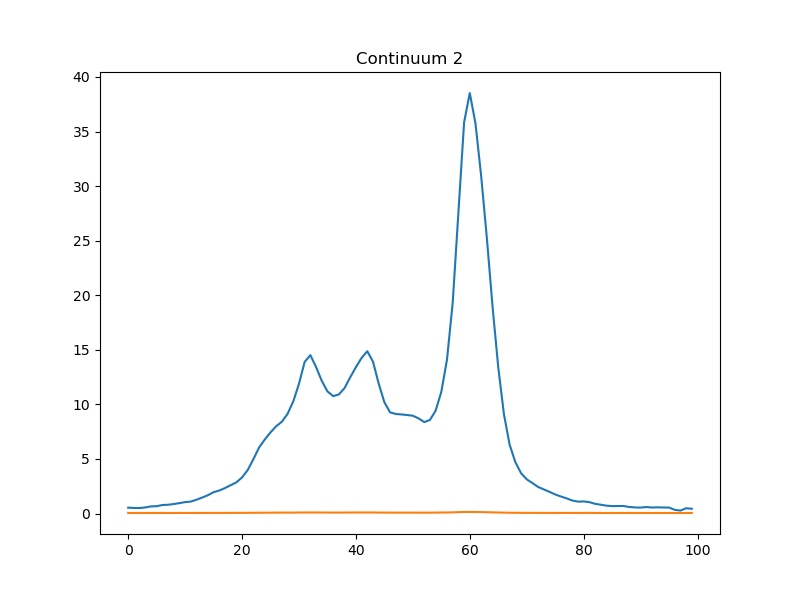

In [97]:
mask_continuum_2 = (wv > 5300)*(wv < 5800)
image_continuum_2 = image_cut[:, mask_continuum_2]
image_error_continuum_2 = image_error_cut[:, mask_continuum_2]
radial_profile_continuum_2 = np.sum(image_continuum_2, axis = 1)
radial_profile_error_continuum_2 = np.sqrt(np.sum(image_error_continuum_2**2, axis = 1))
real_errors_c2 = np.sqrt(radial_profile_error_continuum_2**2+(sky_err[2])**2+(0.04*radial_profile_continuum_2)**2)

plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_2)
plt.plot(x_axes, radial_profile_error_continuum_2)
plt.title(r'Continuum 2')

In [98]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_2, sigmas[5])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 1308.6789798248406
differential_evolution step 2: f(x)= 1308.6789798248406
differential_evolution step 3: f(x)= 526.4443458032512
differential_evolution step 4: f(x)= 526.4443458032512
differential_evolution step 5: f(x)= 526.4443458032512
differential_evolution step 6: f(x)= 526.4443458032512
differential_evolution step 7: f(x)= 392.93063115812066
differential_evolution step 8: f(x)= 369.30033399266364
differential_evolution step 9: f(x)= 369.30033399266364
differential_evolution step 10: f(x)= 366.3754784286185
differential_evolution step 11: f(x)= 366.3754784286185
differential_evolution step 12: f(x)= 366.3754784286185
differential_evolution step 13: f(x)= 295.6497526069467
differential_evolution step 14: f(x)= 295.6497526069467
differential_evolution step 15: f(x)= 295.6497526069467
differential_evolution step 16: f(x)= 295.6497526069467
differential_evolution step 17: f(x)= 295.6497526069467
differential_evolution step 18: f(x)= 295.6497526069

Sérsic 1: I_e=1.0000, r_e=20.5268, n=1.4689, x_0=31.4899
Sérsic 2: I_e=1.0000, r_e=17.0216, n=0.1000, x_0=40.0000
Sérsic 3: I_e=1.0000, r_e=17.7173, n=1.4584, x_0=41.8189
Sérsic 4: I_e=1.0000, r_e=15.8715, n=2.4633, x_0=59.4540
Sérsic 5: I_e=1.0000, r_e=8.4913, n=2.1523, x_0=62.2982


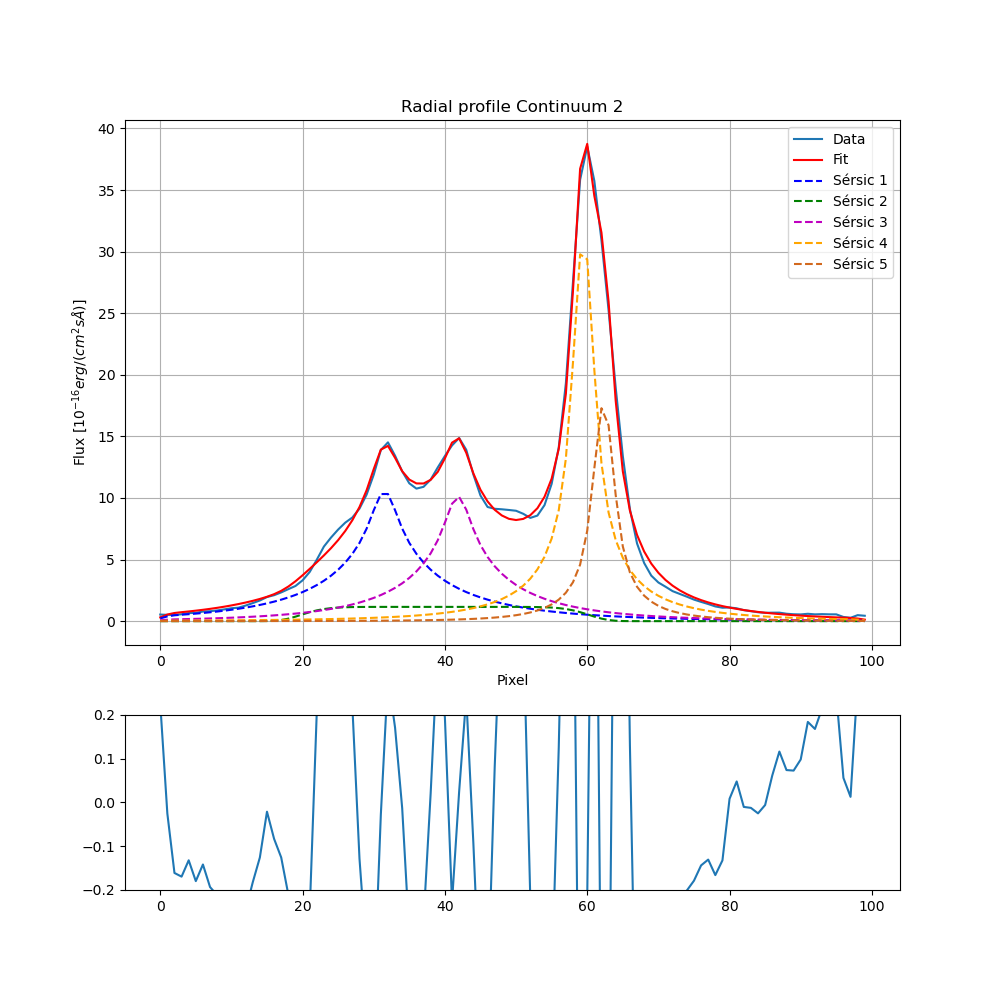

In [99]:
save_params_diff(best_params, radial_profile_continuum_2, real_errors_c2, sigmas[-1],
    x_axes, n_component, line_name="Continuum_2", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_2, sigmas[-1], r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_diff')

In [100]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_2, covariance_continuum_2 = curve_fit(lambda x, *params: model_convolved(x, sigmas[-1], *params), x_axes, radial_profile_continuum_2, p0=result.x, 
                                                             sigma = real_errors_c2, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_2, dof_continuum_2, chi2_continuum_2 = save_params(params_curve_continuum_2, covariance_continuum_2, radial_profile_continuum_2,
                                                                          real_errors_c2, sigmas[-1], x_axes, n_component, line_name="Continuum_2", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=1.0000, r_e=16.1490, n=1.4772, x_0=31.2502
Sérsic 2: I_e=1.0000, r_e=17.2428, n=0.1000, x_0=39.9452
Sérsic 3: I_e=1.0000, r_e=21.1978, n=1.4904, x_0=41.7510
Sérsic 4: I_e=0.6057, r_e=22.3653, n=2.9923, x_0=59.4024
Sérsic 5: I_e=1.0000, r_e=5.4061, n=2.4530, x_0=62.7009
[ 0.99836461 19.97172495  0.67556842  0.26496798  1.08046405 26.55522899
  0.12195855 27.13319401  0.86507035 32.13807964  0.6119995   0.26843557
  1.34473257 36.93278259  1.49778139  0.16894618  2.3162185   9.81283271
  1.52436287  0.28350826]
3.193852547979156


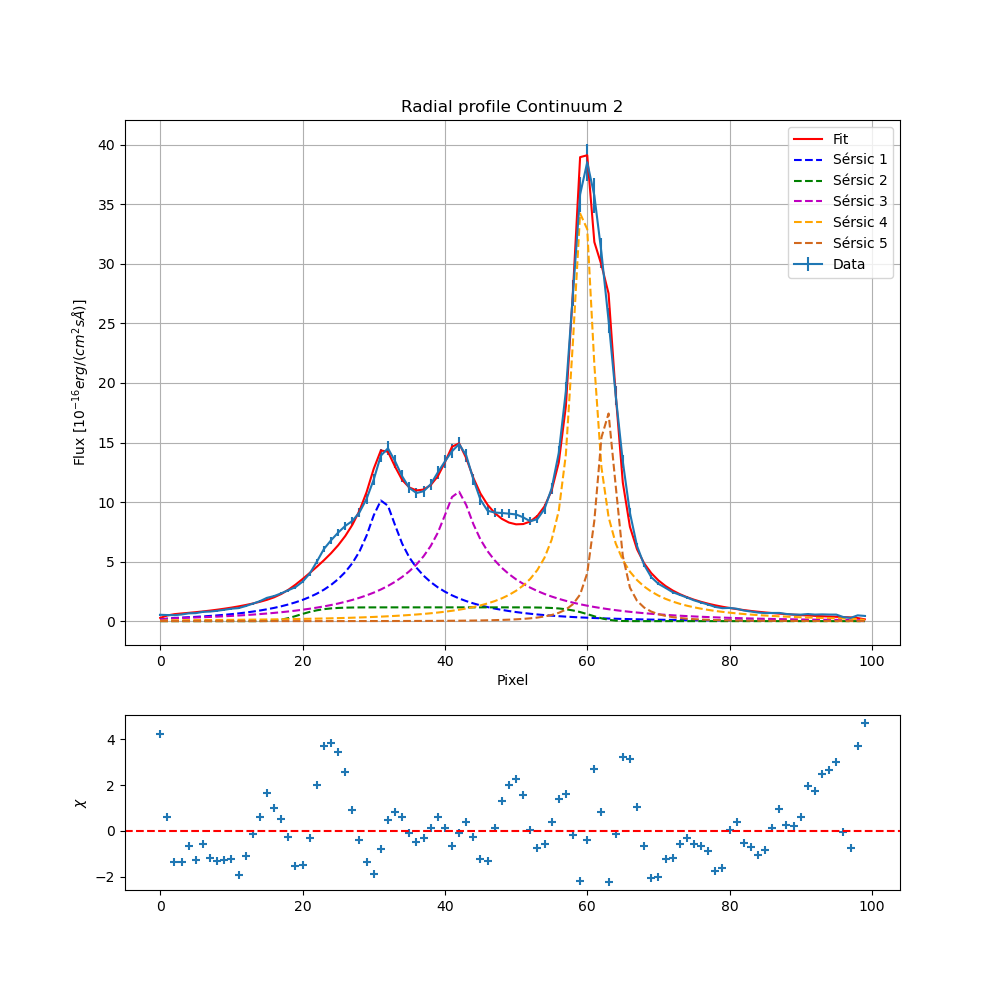

In [101]:
plot_curve(x_axes, params_curve_continuum_2, radial_profile_continuum_2, real_errors_c2, sigmas[-1], r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_curve')

##  Continuum 3

Text(0.5, 1.0, 'Continuum 3')

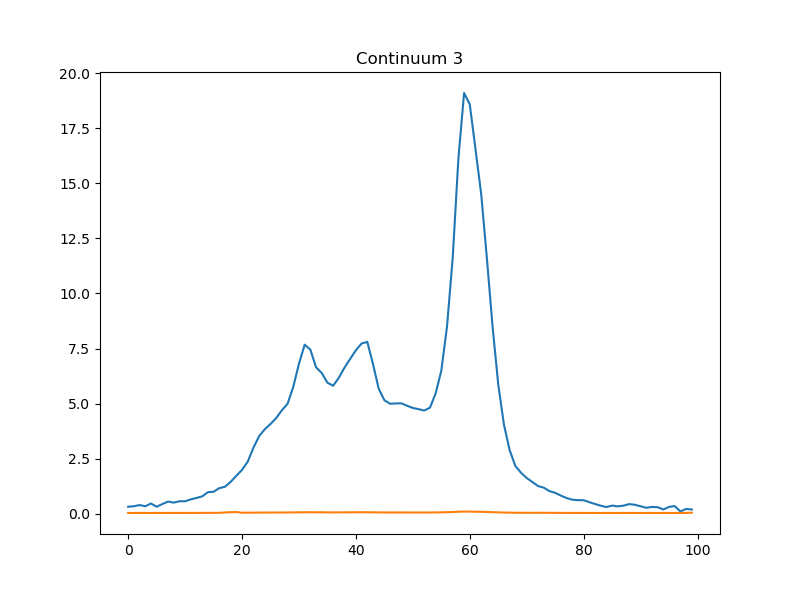

In [102]:
mask_continuum_3 = (wv > 5900)*(wv < 6200)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))
real_errors_c3 = np.sqrt(radial_profile_error_continuum_3**2+(sky_err[2])**2+(0.04*radial_profile_continuum_3)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_3)
plt.plot(x_axes, radial_profile_error_continuum_3)
plt.title(r'Continuum 3')

In [103]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_3, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 819.7006836625384
differential_evolution step 2: f(x)= 556.3310891275034
differential_evolution step 3: f(x)= 526.7352554348514
differential_evolution step 4: f(x)= 196.57789715829605
differential_evolution step 5: f(x)= 196.57789715829605
differential_evolution step 6: f(x)= 196.57789715829605
differential_evolution step 7: f(x)= 196.57789715829605
differential_evolution step 8: f(x)= 168.58241743505747
differential_evolution step 9: f(x)= 168.58241743505747
differential_evolution step 10: f(x)= 168.58241743505747
differential_evolution step 11: f(x)= 141.9223329610231
differential_evolution step 12: f(x)= 121.26362727891744
differential_evolution step 13: f(x)= 121.26362727891744
differential_evolution step 14: f(x)= 121.26362727891744
differential_evolution step 15: f(x)= 121.26362727891744
differential_evolution step 16: f(x)= 84.56486918772544
differential_evolution step 17: f(x)= 84.56486918772544
differential_evolution step 18: f(x)= 84.56486

Sérsic 1: I_e=0.2981, r_e=26.7177, n=1.7465, x_0=31.1185
Sérsic 2: I_e=1.0000, r_e=16.8869, n=0.1000, x_0=40.0000
Sérsic 3: I_e=0.4579, r_e=23.8487, n=1.5173, x_0=41.1100
Sérsic 4: I_e=0.9860, r_e=8.7655, n=1.9527, x_0=58.9928
Sérsic 5: I_e=1.0000, r_e=5.9655, n=1.5914, x_0=61.9967


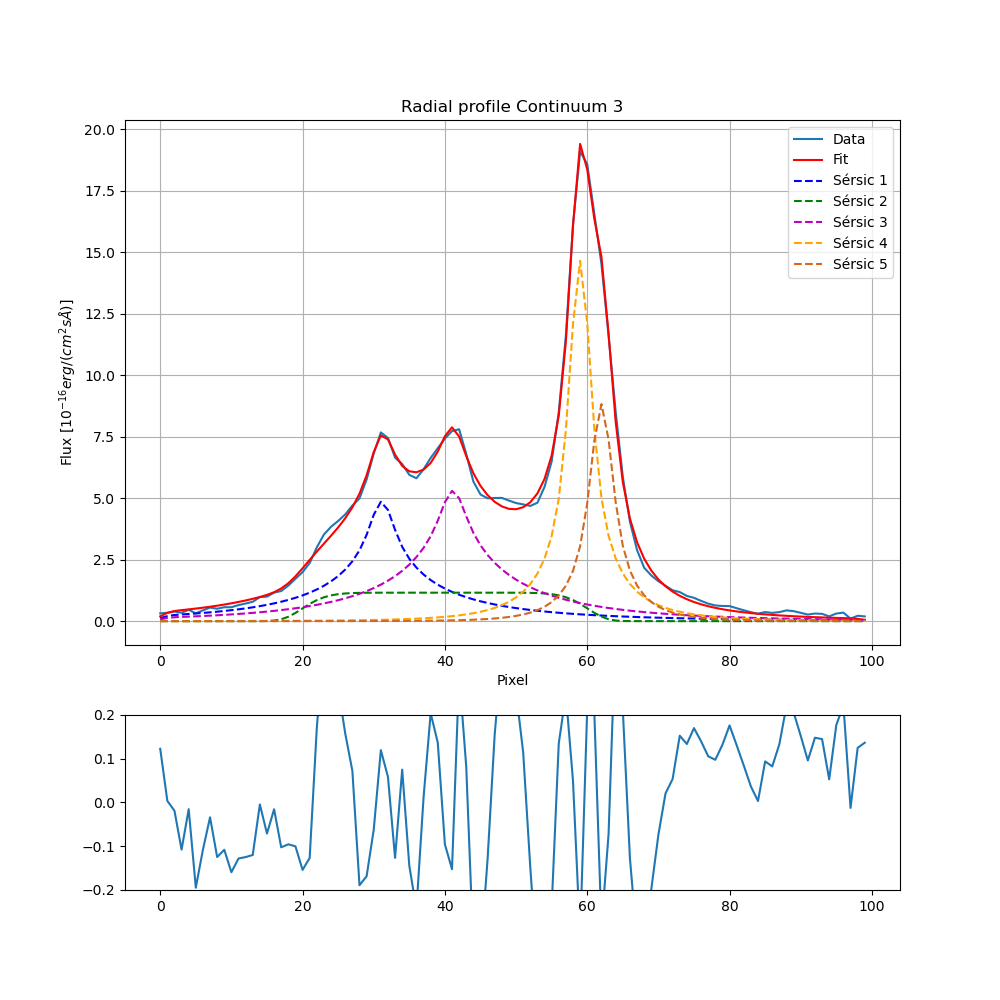

In [104]:
save_params_diff(best_params, radial_profile_continuum_3, real_errors_c3, sigmas[0],
    x_axes, n_component, line_name="Continuum_3", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_diff')

In [105]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_3, covariance_continuum_3 = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes,
                                                             radial_profile_continuum_3, p0=result.x, sigma = real_errors_c3) #, bounds = bounds_list, maxfev = 10000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_3, dof_continuum_3, chi2_continuum_3 = save_params(params_curve_continuum_3, covariance_continuum_3, radial_profile_continuum_3,
                                                                          real_errors_c3, sigmas[0], x_axes, n_component, line_name="Continuum_3", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_20856\637918482.py:11: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_20856\637918482.py:24: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.5659, r_e=15.3245, n=1.3070, x_0=31.1928
Sérsic 2: I_e=0.6591, r_e=22.1746, n=0.0501, x_0=42.7149
Sérsic 3: I_e=0.2773, r_e=30.9922, n=1.8031, x_0=41.1239
Sérsic 4: I_e=0.2687, r_e=25.6345, n=2.8389, x_0=58.8789
Sérsic 5: I_e=2.1229, r_e=3.0405, n=1.0420, x_0=61.8312
[ 0.27503056  8.36782339  0.32710576  0.26010336  0.75615276  2.53984939
  0.03156972  1.13141312  0.13055611 23.65680867  0.32087807  0.21314817
  0.34726515 25.45296451  0.85086426  0.1852364   1.21295963  0.52916082
  0.44963374  0.36235326]
1.5210282061801759


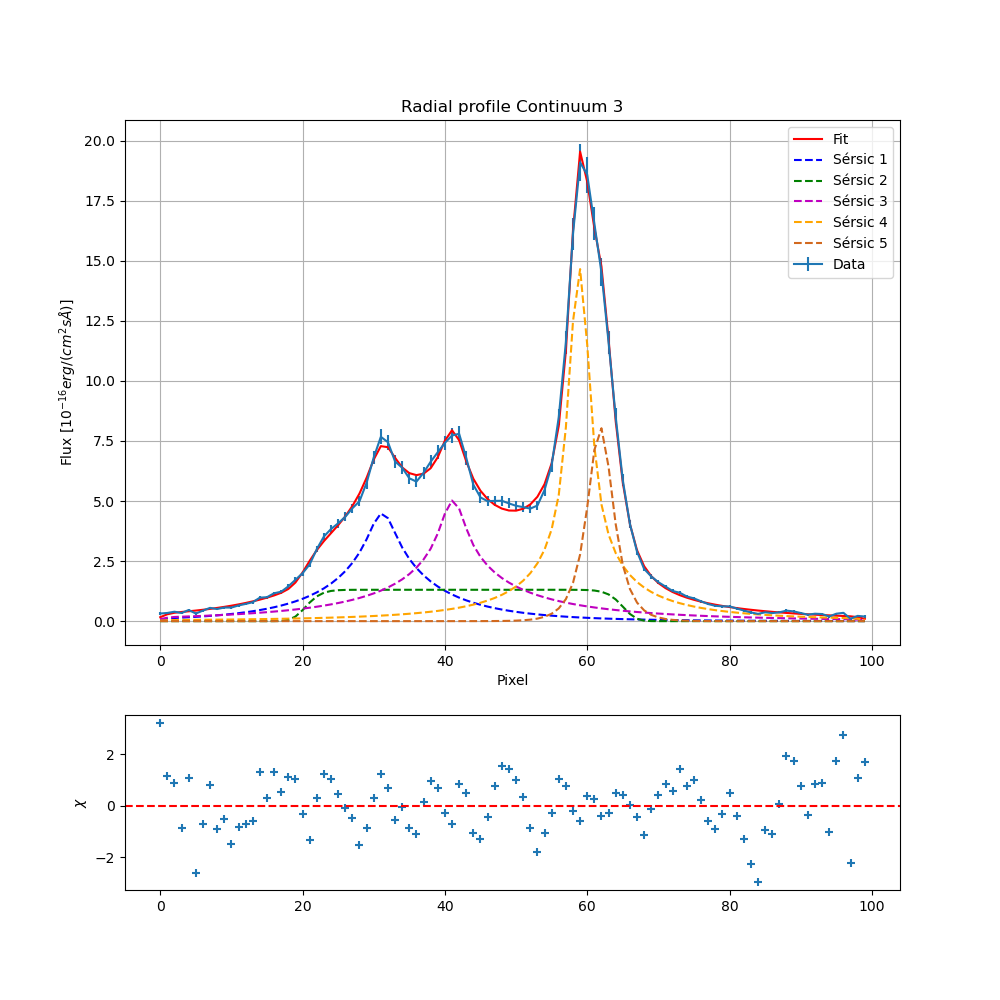

In [106]:
plot_curve(x_axes, params_curve_continuum_3, radial_profile_continuum_3, real_errors_c3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_curve')

## Chi squared save

In [107]:
chi_red = [chi2_reduced_continuum_1, chi2_reduced_continuum_2, chi2_reduced_continuum_3]
dof = [dof_continuum_1, dof_continuum_2, dof_continuum_3]
chi = [chi2_continuum_1, chi2_continuum_2, chi2_continuum_3]

d1 = {'Name': ['Continuum 1', 'Continuum 2', 'Continuum 3'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit_continuum.csv", index= False)

## Halpha and continuum

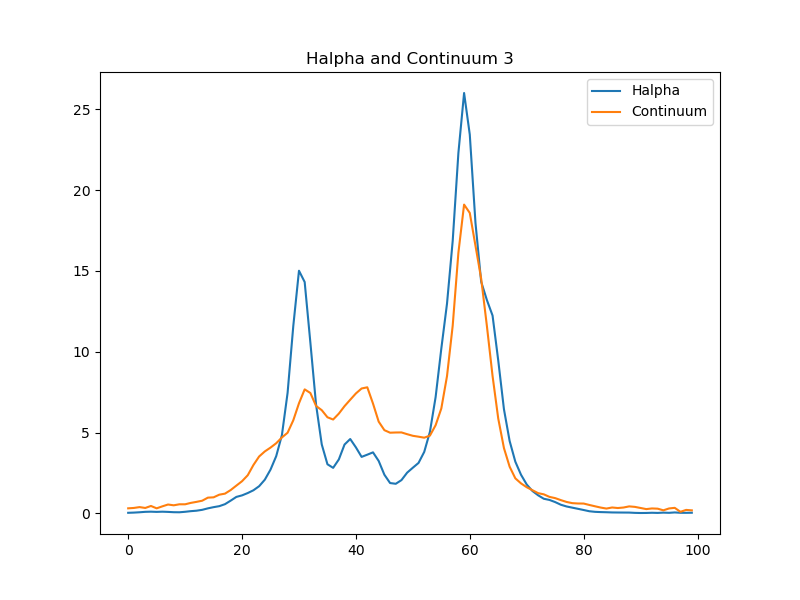

In [111]:
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_HA, label = 'Halpha') 
plt.plot(x_axes, radial_profile_continuum_3, label = 'Continuum')
plt.title(r'Halpha and Continuum 3')
plt.legend()